Top-level keys: ['data']

Keys in data: ['demo_0']
Key for demo_0: <KeysViewHDF5 ['chunk_0']>
Key for agentview image: (103, 2, 128, 128, 3)
(128, 128, 3)


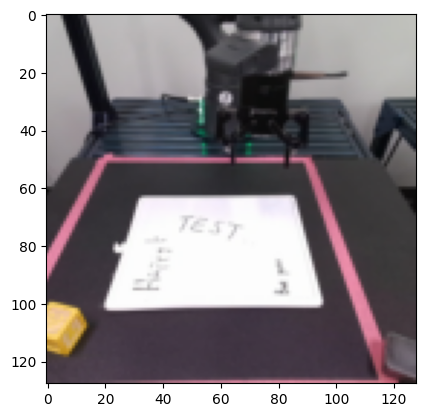

In [38]:
import h5py
import cv2
import matplotlib.pyplot as plt

# Open the HDF5 file
test_path = "../../demos/pick_cube_1105_30demos/1105_221848.hdf5" # '../demos/1029_multiview/demo.hdf5'
test_path = "/home/mbronars/zhenyang/demos/2024-12-27/1227_124821.hdf5"
test_path = "/home/mbronars/zhenyang/demos/wiping_test_1227/2024-12-27/1227_172252.hdf5"
with h5py.File(test_path, 'r') as f:
    # Print all top-level keys
    print("Top-level keys:", list(f.keys()))
    
    # Print keys in observations group if it exists
    if 'observations' in f:
        print("\nKeys in observations:", list(f['observations'].keys()))
        
    # Print keys in any other groups
    for key in f.keys():
        if isinstance(f[key], h5py.Group):
            print(f"\nKeys in {key}:", list(f[key].keys()))
            
    for demo in list(f['data'].keys()):
        print(f"Key for {demo}: {f['data'][demo].keys()}")

    # print(f"Key for actions: {f['data']['demo_0']['chunk_0']['states'].shape}")
    image = f['data']['demo_0']['chunk_0']['obs/agentview_image'][...]
    print(f"Key for agentview image: {f['data']['demo_0']['chunk_0']['obs/agentview_image'].shape}")

    # print(f"Key for actions: {f['data']['demo_0']['states'].shape}")
    # print(f"Key for actions: {f['data']['demo_0']['agentview_images'].shape}")
    # print(f"Key for actions: {f['data']['demo_0']['robot0_eye_in_hand_image'].shape}")

    # cv2.imshow(image[3,-1,...])
    # print(image[1,1,1,:,:])
    print(image[0,-1,:,:,:].shape)
    plt.imshow(image[0,-1,:,:,:])
    plt.show()


image observations: (59, 128, 128, 3)
demo number: 200


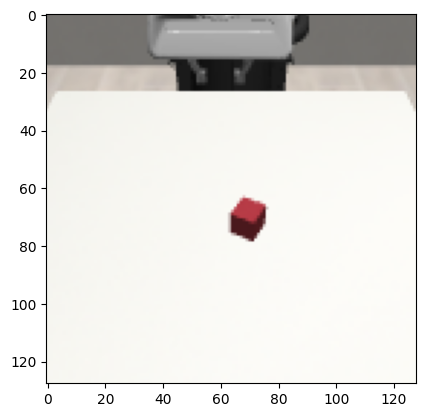

In [33]:
# python ./scripts/dataset_states_to_obs.py --dataset ../datasets/lift/ph/low_dim_v141.hdf5 --output_name image.hdf5 --done_mode 2 --camera_names agentview robot0_eye_in_hand --camera_height 128 --camera_width 128
import matplotlib.pyplot as plt

test_path = "/home/mbronars/zhenyang/robomimic-nadun/datasets/lift/ph/all_obs_v141.hdf5"
with h5py.File(test_path, 'r') as f:
    print(f"image observations: {f['data']['demo_0']['obs/agentview_image'].shape}")
    
    demos_name = list(f['data'].keys())
    print(f"demo number: {len(demos_name)}")
    images = f['data']['demo_0']['obs/agentview_image']

    plt.imshow(images[0])
    plt.show()

In [12]:
import torch

params = torch.load("/home/mbronars/zhenyang/robomimic-nadun/dp_trained_models/sim/pick_cube_osc_desired_sim/20241113050225/models/model_epoch_600.pth")

params_real = torch.load("/home/mbronars/zhenyang/robomimic-nadun/dp_trained_models/pick_cube_osc_desired_pose_1110_ep600.pt")

params = params_real

print(params['model']['nets'].keys())
print(params['model']['ema'].keys())

odict_keys(['policy.obs_encoder.nets.obs.obs_nets.agentview_image.backbone.nets.0.weight', 'policy.obs_encoder.nets.obs.obs_nets.agentview_image.backbone.nets.1.weight', 'policy.obs_encoder.nets.obs.obs_nets.agentview_image.backbone.nets.1.bias', 'policy.obs_encoder.nets.obs.obs_nets.agentview_image.backbone.nets.4.0.conv1.weight', 'policy.obs_encoder.nets.obs.obs_nets.agentview_image.backbone.nets.4.0.bn1.weight', 'policy.obs_encoder.nets.obs.obs_nets.agentview_image.backbone.nets.4.0.bn1.bias', 'policy.obs_encoder.nets.obs.obs_nets.agentview_image.backbone.nets.4.0.conv2.weight', 'policy.obs_encoder.nets.obs.obs_nets.agentview_image.backbone.nets.4.0.bn2.weight', 'policy.obs_encoder.nets.obs.obs_nets.agentview_image.backbone.nets.4.0.bn2.bias', 'policy.obs_encoder.nets.obs.obs_nets.agentview_image.backbone.nets.4.1.conv1.weight', 'policy.obs_encoder.nets.obs.obs_nets.agentview_image.backbone.nets.4.1.bn1.weight', 'policy.obs_encoder.nets.obs.obs_nets.agentview_image.backbone.nets.4.1

In [14]:
from termcolor import cprint

aa = 100
cprint(f"warning test{aa}", "red")

warning test100


In [10]:
import h5py
sim_dataset_path = "/home/mbronars/zhenyang/robomimic-nadun/datasets/lift/ph/all_obs_v141.hdf5"
real_dataset_path = "/home/mbronars/zhenyang/demos/pick_cube_1105_30demos/pick_cube_1106/pick_cube_1106_demo.hdf5"

dataset_path = real_dataset_path

with h5py.File(dataset_path, 'r') as f:
    print(f"actions keys: {f['data']['demo_0'].keys()}")
    print(f"gripper position: {f['data']['demo_0']['obs/gripper_position'][...]}")
    print(f"actions: {f['data']['demo_0']['actions'][...]}")


actions keys: <KeysViewHDF5 ['absolute_actions', 'actions', 'control_enabled', 'delta_actions', 'dones', 'obs', 'rewards']>
gripper position: [0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.08370044 0.15859031 0.23788546 0.33920705 0.4185022
 0.48898678 0.49339207 0.49339207 0.49339207 0.49339207 0.49339207
 0.49339207 0.49339207 0.49339207 0.49339207 0.49339207 0.49339207
 0.49339207 0.49339207 0.49339207 0.49339207 0.49339207 0.49339207
 0.49339207 0.49339207 0.49339207 0.49339207 0.49339207 0.49

## Inference in sim model and test

demo keys: <KeysViewHDF5 ['absolute_actions', 'actions', 'delta_joint_actions', 'dones', 'joint_position_actions', 'obs', 'reached_pose_action', 'rewards', 'states']>
obs keys: <KeysViewHDF5 ['actions', 'object', 'robot0_eef_pos', 'robot0_eef_quat', 'robot0_eef_vel_ang', 'robot0_eef_vel_lin', 'robot0_gripper_qpos', 'robot0_gripper_qvel', 'robot0_joint_pos', 'robot0_joint_pos_cos', 'robot0_joint_pos_sin', 'robot0_joint_vel', 'timesteps']>
eef pos shape: (44, 3)
eef quat shape: (44, 4)
actions shape: (44, 7)
timesteps: [[ 0]
 [ 0]
 [ 1]
 [ 2]
 [ 3]
 [ 4]
 [ 5]
 [ 6]
 [ 7]
 [ 8]
 [ 9]
 [10]
 [11]
 [12]
 [13]
 [14]
 [15]
 [16]
 [17]
 [18]
 [19]
 [20]
 [21]
 [22]
 [23]
 [24]
 [25]
 [26]
 [27]
 [28]
 [29]
 [30]
 [31]
 [32]
 [33]
 [34]
 [35]
 [36]
 [37]
 [38]
 [39]
 [40]
 [41]
 [42]]
[-0.26410031 -0.30568206 -0.29630238 -0.37696776 -0.38146815 -0.39539868
 -0.54203653 -0.52933347 -0.41060981 -0.50757426 -0.5266251  -0.61423045
 -0.71133852 -0.6725952  -0.59158725 -0.47336143 -0.43935597 -0.42

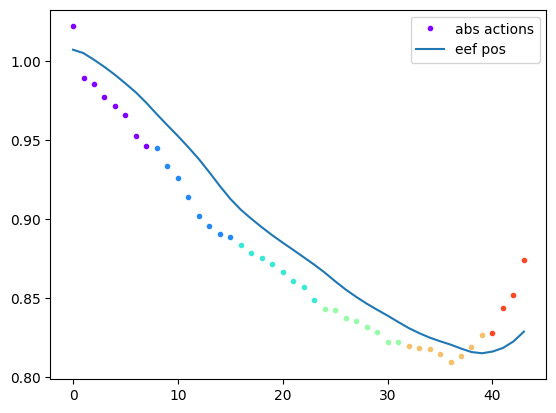

In [56]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

dataset_path = "/home/mbronars/zhenyang/demos/pick_cube_sim_infer_1114.hdf5"

with h5py.File(dataset_path, 'r') as f:
    print(f"demo keys: {f['data']['demo_0'].keys()}")
    states = f['data']['demo_0']['states'][...] # low dim simulation states
    actions = f['data']['demo_0']['actions'][...]
    abs_actions = f['data']['demo_0']['absolute_actions'][...]
    print(f"obs keys: {f['data']['demo_0']['obs'].keys()}")
    obs_eef_pos = f['data']['demo_0']['obs']['robot0_eef_pos'][...]
    obs_eef_quat = f['data']['demo_0']['obs']['robot0_eef_quat'][...]
    obs_joint_pos = f['data']['demo_0']['obs']['robot0_joint_pos'][...]
    obs_joint_vel = f['data']['demo_0']['obs']['robot0_joint_vel'][...]
    obs_actions = f['data']['demo_0']['obs']['actions'][...]
    
    timesteps = f['data']['demo_0']['obs']['timesteps'][...]

print(f"eef pos shape: {obs_eef_pos.shape}")
print(f"eef quat shape: {obs_eef_quat.shape}")
print(f"actions shape: {actions.shape}")
# print(f"timesteps: {timesteps}")

plt.close('all')  # Close all existing plots before creating new one

dim = 2
print(actions[:,dim])
fig = plt.figure()
# for i in range(0, len(abs_actions), 8):
#     end_idx = min(i + 8, len(abs_actions))
#     plt.plot(range(i, end_idx), abs_actions[i:end_idx, dim], label="abs actions" if i == 0 else "", 
#              color=plt.cm.rainbow(i/len(abs_actions)))
for i in range(0, len(abs_actions), 8):
    end_idx = min(i + 8, len(abs_actions))
    plt.plot(range(i, end_idx), abs_actions[i:end_idx, dim], '.', 
             label="abs actions" if i == 0 else "",
             color=plt.cm.rainbow(i/len(abs_actions)))
plt.plot(obs_eef_pos[:, dim], label="eef pos")
plt.legend()
plt.show()

## Plot the actions and eef pos
1. Need: time-sync data on action prediction, sequence and actual action (blended action)
 the actions and eef pos.

In [1]:
import robomimic.utils.file_utils as FileUtils

# ckpt_path = "/home/mbronars/zhenyang/robomimic-nadun/dp_trained_models/real_robot/pick_cube_joint_reached_pos_franka_1106/20241106233746/models/model_epoch_1000.pth"
ckpt_path = "/home/mbronars/zhenyang/robomimic-nadun/dp_trained_models/pick_cube_joint_reached_pose_1110_ep1000.pt"
# ckpt_path = "/home/mbronars/zhenyang/robomimic-nadun/dp_trained_models/pick_cube_osc_desired_pose_1110_ep1000.pt"
algo_name, ckpt_dict = FileUtils.algo_name_from_checkpoint(ckpt_path=ckpt_path)
config, _ = FileUtils.config_from_checkpoint(ckpt_dict=ckpt_dict)

# print(config)

/home/mbronars/.local/lib/python3.8/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [13]:
# %matplotlib widget
import h5py
import matplotlib.pyplot as plt
import numpy as np

# need a function to plot 3D trajectory. Given an array of [n, 3] with length n and 3 for xyz. Plot the trajectory in the space. Offer common line style as input since I need to plot several traj in the same plot. If can do it interactively in notebook, it will be better.
def plot_3d_trajectory(traj_data, line_style='-', color=None, label=None, alpha=1.0, marker=None):
    """Plot a 3D trajectory.
    
    Args:
        traj_data (np.ndarray): Array of shape [n,3] containing xyz coordinates
        line_style (str): Line style for plotting ('-', '--', ':', etc)
        color (str): Color of the trajectory
        label (str): Label for the legend
        alpha (float): Transparency value between 0 and 1
        marker (str): Marker style ('o', '.', etc)
    
    Returns:
        fig: matplotlib figure handle
    """
    import matplotlib.pyplot as plt
    from mpl_toolkits.mplot3d import Axes3D
    
    # Create 3D plot
    fig = plt.figure(figsize=(10,10))
    ax = fig.add_subplot(111, projection='3d')
    
    # Plot trajectory
    ax.plot(traj_data[:,0], traj_data[:,1], traj_data[:,2],
            linestyle=line_style, color=color, label=label, 
            alpha=alpha, marker=marker)
    
    # Labels and title
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title('3D Trajectory')
    
    if label is not None:
        ax.legend()
        
    # Make the plot more interactive in notebook
    plt.show()
    return fig

# Example usage:
# plot_3d_trajectory(traj_data=inference_obs, 
#                   line_style='-', color='blue', label='Actual Path')
# plot_3d_trajectory(traj_data=inference_action_seq[0], 
#                   line_style='--', color='red', label='Predicted Path')

# dataset_path = "/home/mbronars/zhenyang/demos/pick_cube_osc_sim_1124_RHC_act_prefill.hdf5"
# dataset_path = "/home/mbronars/zhenyang/demos/pick_cube_osc_franka_80hz_seq.hdf5"
# dataset_path = "/home/mbronars/zhenyang/demos/pick_cube_1205_20hz_seq.hdf5"

dataset_path  = "/home/mbronars/zhenyang/rollout_data/0111_wiping_seq_20hz.hdf5"

with h5py.File(dataset_path, 'r') as f:
    t_finish_infer = f['data']['demo_0']['inference_t'][...]
    inference_action_seq = f['data']['demo_0']['inference_action_seq'][...]
    inference_obs = f['data']['demo_0']['inference_obs']['robot0_eef_pos'][...]
    print(f"inference_obs keys: {f['data']['demo_0']['inference_obs'].keys()}")
    inference_obs_timesteps = f['data']['demo_0']['inference_obs']['time'][...]

    step_obs = f['data']['demo_0']['obs']['robot0_eef_pos'][...]
    action_taken = f['data']['demo_0']['actions'][...]
    # print(f"demo keys: {f['data']['demo_0'].keys()}")
    # print(f"actions: {f['data']['demo_0']['actions'][...].shape}")
    # print(f"obs keys: {f['data']['demo_0']['obs'].keys()}")
    # print(f"obs/agentview_image: {f['data']['demo_0']['obs']['agentview_image'][...].shape}")

# this is for the controlled group dataset
original_dataset_path = "/home/mbronars/zhenyang/demos/pick_cube_sim_infer_1116_original.hdf5"
with h5py.File(original_dataset_path, 'r') as f:
    print(f"demo keys: {f['data']['demo_0'].keys()}")
    controlled_states = f['data']['demo_0']['states'][...] # low dim simulation states
    controlled_actions = f['data']['demo_0']['actions'][...]

inference_action_seq = np.squeeze(inference_action_seq)
inference_obs = np.squeeze(inference_obs)
t_finish_infer -= t_finish_infer[0]

print(f"t_finish_infer: {t_finish_infer.shape}")
print(f"inference_action_seq: {inference_action_seq.shape}")
print(f"inference_obs: {inference_obs.shape}")
print(f"action_taken: {action_taken.shape}")
print(f"step obs shape: {step_obs.shape}")
# print(f"time stamps: {np.unique(inference_obs_timesteps)}")
# print(f"step_obs: {np.round(step_obs, decimals=3)}")

# plot_3d_trajectory(traj_data=inference_obs[:, -1, :], line_style='-', color='blue', label='Actual Path')
# plot_3d_trajectory(traj_data=inference_action_seq[0], line_style='--', color='red', label='Predicted Path')

fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(t_finish_infer, inference_obs[:, -1, 2], 'o', label='Z obs vs time')
ax.plot(t_finish_infer, action_taken[:, 2], 'x', label='Z action vs time')
ax.plot(t_finish_infer, step_obs[:, 2], 'x', label='Z step obs vs time')
ax.legend()
plt.show()

KeyError: "Unable to synchronously open object (object 'inference_obs' doesn't exist)"

## Plot traj and action for z axis only
Note: action is delta action here
Plot:
1. Actual traj
2. Actual actions
3. Generated actions (the one used for ensemble)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


inference_obs_timesteps: [0.        0.        0.        1.3845818 1.7254949 1.7532887 1.7928207
 1.8428664 1.8927693 1.9423523 1.9920249 2.042618  2.092329  2.1425993
 2.1923294 2.2427573 2.292498  2.3435261 2.392456  2.442707  2.4927332
 2.5429425 2.5927656 2.643119  2.6935036 2.7438116 2.7938447 2.8434112
 2.8914587 2.9436264 2.9937346 3.043285  3.093772  3.1441212 3.1938708
 3.2439814 3.294052  3.3446977 3.3947725 3.4441156 3.494158  3.5440695
 3.5941145 3.6445847 3.6942973 3.7446795 3.794429  3.8455338 3.8949392]
time interval: [0.0, 0.0, 1.3845818, 0.34091306, 0.027793884, 0.039531946, 0.05004573, 0.049902916, 0.04958296, 0.049672604, 0.050593138, 0.04971099, 0.05027032, 0.049730062, 0.050427914, 0.04974079, 0.051028013, 0.04892993, 0.050251007, 0.05002618, 0.050209284, 0.049823046, 0.050353527, 0.05038452, 0.05030799, 0.050033092, 0.049566507, 0.048047543, 0.052167654, 0.050108194, 0.049550295, 0.05048704, 0.050349236, 0.049749613, 0.05011058, 0.050070524, 0.05064583, 0.050074816

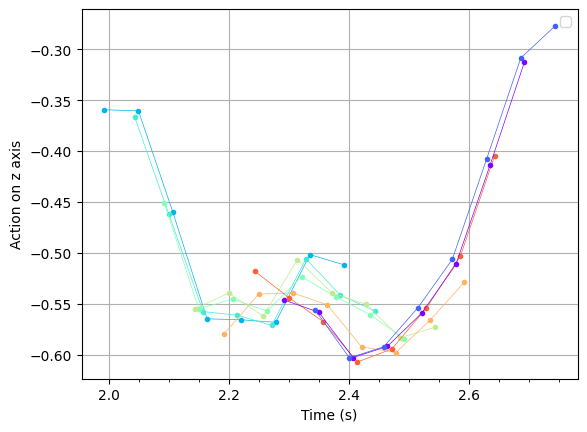

In [24]:
def plot_1dim_traj(ax, traj_data, t_span, label, color, marker):
    """
    Given a figure, plot the 1D traj data. (can be obs or action)
    """
    ax.plot(t_span, traj_data, label=label, color=color, marker=marker, linewidth=0.5)
    return ax

dt = 0.05
act_horizon = inference_action_seq.shape[1] # prediction horizons
# plot all the predicted actions (z-axis)
fig = plt.figure()
ax = fig.add_subplot(111)
# TODO: current timesteps wrt to inference ONLY, not align to observation
start_plot_t = 10
end_plot_t = 18

if inference_obs_timesteps.ndim > 1:
    inference_obs_timesteps = np.squeeze(inference_obs_timesteps)
    inference_obs_timesteps -= inference_obs_timesteps[0]
print(f"inference_obs_timesteps: {inference_obs_timesteps}")
time_interval = [inference_obs_timesteps[i+1] - inference_obs_timesteps[i] for i in range(len(inference_obs_timesteps)-1)]
print(f"time interval: {time_interval}")

### Every action prediction
for t in range(start_plot_t, end_plot_t):
    t_start = inference_obs_timesteps[t] # actual start time of the action (observation timestamp)
    # print(f"timestep {t}, Inference starts at {t_start}s")
    t_span = np.linspace(t_start, t_start+act_horizon*dt, act_horizon)
    color_idx = (t%act_horizon)/act_horizon
    plot_1dim_traj(ax, inference_action_seq[t, :, 2], t_span, label=None, color=plt.cm.rainbow(color_idx), marker='.')
    ## Plot z obervation used for inference
    # plt.plot(t_span[0], inference_obs[t, -1, 2], color='black', marker='x')

t_all = np.linspace(start_plot_t*dt, (end_plot_t-1)*dt, end_plot_t-start_plot_t) #inference_action_seq.shape[0])
### Plot the real taken action
# plot_1dim_traj(ax, action_taken[start_plot_t:end_plot_t, 2], t_all, label="actual action", color='black', marker='x')
### Plot the observation (current state)
### Plot the inference observation position
# t_inf_start = inference_obs_timesteps[start_plot_t]
# t_all_inf = np.linspace(t_inf_start, t_inf_start + )
# plot_1dim_traj(ax, [t_inf_start: t_end_plot_t, 2], t_all, label="actual action", color='black', marker='x')

# TODO: fix timestamp for the observation. Misaglinment with inference

# ax.plot(t_all, step_obs[start_plot_t: end_plot_t, 2], 'x', label='Z step obs vs time')
ax.grid(True)
ax.xaxis.set_major_locator(plt.MultipleLocator(0.2))  # Major grid lines every 0.5 units
ax.xaxis.set_minor_locator(plt.MultipleLocator(0.05))  # Minor grid lines every 0.1 units
plt.xlabel("Time (s)")
plt.ylabel("Action on z axis")
plt.legend()
# plt.savefig("/home/mbronars/zhenyang/demos/figs/osc_sim.png")
plt.show()


## Plot taken actions the observation

inference_action_seq: (800, 12, 8)
inference_t: (800,)
action_taken: (800, 14)
step obs shape: (800, 6)


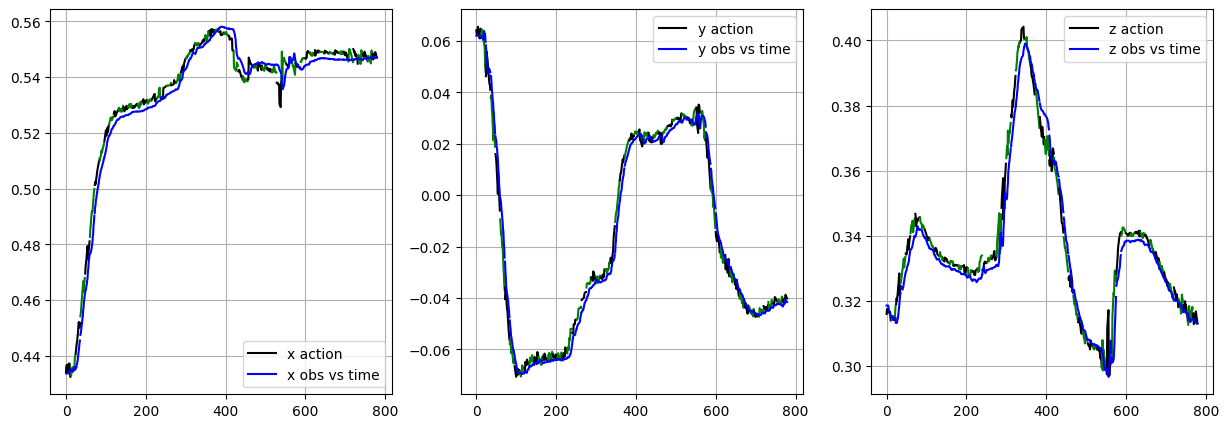

In [36]:
import h5py
import os
import numpy as np
import matplotlib.pyplot as plt

# dataset_path = "/home/mbronars/zhenyang/demos/pick_cube_1208_20hz_seq_high_gain.hdf5"
# dataset_path = "/home/mbronars/zhenyang/demos/pick_cube_1210_80hz_horizon12_demo_replay.hdf5"
dataset_path = "/home/mbronars/zhenyang/demos/pick_cube_osc_1213_80hz_FF_act12.hdf5"
dataset_path = "/home/mbronars/zhenyang/rollout_data/0111_wiping_seq_20hz.hdf5"
# dataset_path = "/home/mbronars/zhenyang/rollout_data/0111_wiping_action_schedule_40hz_inpaint.hdf5"
# dataset_path = "/home/mbronars/zhenyang/rollout_data/0111_wiping_action_schedule_20hz_inpaint_FF.hdf5"

# dataset_path = "/home/mbronars/zhenyang/rollout_data/0121_stacking_cups_reached.hdf5"
dataset_path = "/home/mbronars/zhenyang/rollout_data/0121_stacking_cups_desired.hdf5"
dataset_path = "/home/mbronars/zhenyang/rollout_data/0121_stacking_cups_reached_Kp300.hdf5"

with h5py.File(dataset_path, 'r') as f:
    t_finish_infer = f['data']['demo_0']['inference_t'][...]
    inference_action_seq = f['data']['demo_0']['inference_action_seq'][...]
    inference_t = f['data']['demo_0']['inference_t'][...]

    step_obs = f['data']['demo_0']['obs']['eef_pose'][...]
    action_taken = f['data']['demo_0']['actions'][...]

    # time = f['data']['demo_0']['obs']['time'][...] # works for 1205
    # timesteps = f['data']['demo_0']['obs']['timesteps'][...]

    # time = f['data']['demo_0']['obs']['agentview_dev_timestamp'][...] # camera frames timestamp that used to inference (from stacked queue)
    time = f['data']['demo_0']['obs']['timestamp'][...]

inference_action_seq = np.squeeze(inference_action_seq)
# inference_obs = np.squeeze(inference_obs)

print(f"inference_action_seq: {inference_action_seq.shape}")
print(f"inference_t: {inference_t.shape}")
print(f"action_taken: {action_taken.shape}")
print(f"step obs shape: {step_obs.shape}")

# plot_3d_trajectory(traj_data=action_taken, line_style='-', color='blue', label='Action Path')
# plot_3d_trajectory(traj_data=inference_action_seq[0], line_style='--', color='red', label='Predicted Path')

horizon=12
time_stamp = time - time[0]
all_steps = list(range(step_obs.shape[0]))
x_axis_legend = all_steps # timesteps #  time - time[0]
# print(f"observation timesteps shape {timesteps.shape} timestep final {timesteps[-1]}")
# print(f"camera image timestamp {time_stamp}")
# print(f"inference timestamp {inference_t}")
fig = plt.figure(figsize=(15, 5))
ax = fig.subplots(1, 3)
# ax.plot(x_axis_legend, inference_obs[:, -1, 2], 'o', label='Z obs vs time'

labels = ['x', 'y', 'z']
# Plot for xyz axes
for axis in range(3):
    for pred_num in range(action_taken.shape[0]//horizon-1):
    # for pred_num in range(6):
        # plot every 8 action seq in different color or style
        # print(f"x axis {x_axis_legend[pred_num*horizon: (pred_num+1)*horizon]} value {action_taken[pred_num*horizon: (pred_num+1)*horizon, 2]}")
        if pred_num % 2 == 0:
            ax[axis].plot(x_axis_legend[pred_num*horizon: (pred_num+1)*horizon], action_taken[pred_num*horizon: (pred_num+1)*horizon, axis], '-k', label=f'{labels[axis]} action' if pred_num==0 else None)
        else:
            ax[axis].plot(x_axis_legend[pred_num*horizon: (pred_num+1)*horizon], action_taken[pred_num*horizon: (pred_num+1)*horizon, axis], '-g', fillstyle='none') #, label='X action vs time')

    # observation for each step
    for pred_num in range(step_obs.shape[0]//horizon-1):
        if pred_num % 2 == 0:
            ax[axis].plot(x_axis_legend[pred_num*horizon: (pred_num+1)*horizon], step_obs[pred_num*horizon: (pred_num+1)*horizon, axis], '-b', label=f'{labels[axis]} obs vs time' if pred_num == 0 else None)
        else:
            ax[axis].plot(x_axis_legend[pred_num*horizon: (pred_num+1)*horizon], step_obs[pred_num*horizon: (pred_num+1)*horizon, axis], '-b', fillstyle='none')

    ax[axis].legend()
    ax[axis].grid()


# plt.title(os.path.basename(dataset_path))
plt.savefig(f"/home/mbronars/zhenyang/output/{os.path.basename(dataset_path)}.png")
plt.show()

For debugging runtime in pycharm:

plt.imshow(np.swapaxes(obs_dict['agentview_image'][0,-1,...].cpu().numpy(), 0, 2))

In [2]:
import h5py
import matplotlib.pyplot as plt

# real_robot_path = "/home/mbronars/zhenyang/demos/pick_cube_osc_franka_80hz_seq.hdf5"
real_robot_path = "/home/mbronars/zhenyang/demos/test_1218.hdf5"

# real_robot_path = "/home/mbronars/zhenyang/demos/pick_cube_1030/pick_cube_1030_demo.hdf5"
real_robot_path = "/home/mbronars/zhenyang/demos/pick_cube_1105_30demos/pick_cube_1106/pick_cube_1106_demo.hdf5"

# real_robot_path = "/home/mbronars/zhenyang/demos/wiping_board_1227/2024-12-27_demo_128x128.hdf5"
# real_robot_path= "/home/mbronars/zhenyang/demos/wiping_board_1227/2024-12-27_demo.hdf5"
# real_robot_path = "/home/mbronars/zhenyang/demos/wiping_board_large_0107_demo/2025-01-07_demo.hdf5"
real_robot_path = "/home/mbronars/zhenyang/demos/wiping_board_0105_test/test_demo.hdf5"

with h5py.File(real_robot_path, 'r') as f:
    images_obs = f['data']['demo_0']['obs']['agentview_image'][...]
    # states = f['data']['demo_0']['states'][...] # low dim simulation states
    states = f['data']['demo_0']['obs']['eef_pose'][...]
    # actions = f['data']['demo_0']['actions'][...]
    abs_actions = f['data']['demo_0']['absolute_actions'][...]

print(images_obs.shape)

# images_obs.swapaxes(1,3)
plt.imshow(images_obs[200,...]) # for training demo
# plt.imshow(images_obs[21,-1,...]) # for real robot
print(f"abs action {abs_actions.shape}")
print(f"state {states.shape}")

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/home/mbronars/zhenyang/demos/wiping_board_0105_test/test_demo.hdf5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

## Test Demos Before processing

(199, 512, 512, 3)
abs action (199, 7)
state [[ 0.43373606  0.06223567  0.3182144  -3.13487053  0.13176234 -0.09563656]
 [ 0.43373644  0.06223239  0.31821188 -3.13486791  0.1317746  -0.09562933]
 [ 0.43373664  0.06223712  0.31821365 -3.13487005  0.13174838 -0.09563934]
 ...
 [ 0.53704168  0.00899617  0.41195961  3.12466502  0.06966958 -0.08889255]
 [ 0.53737452  0.01041289  0.41145746  3.12617636  0.0633946  -0.08719423]
 [ 0.53781908  0.01186922  0.41083956  3.1271708   0.05746536 -0.08485316]]


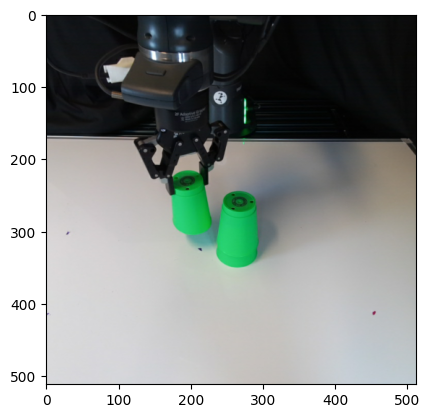

In [10]:
import h5py
import matplotlib.pyplot as plt

# real_robot_path = "/home/mbronars/zhenyang/demos/pick_cube_osc_franka_80hz_seq.hdf5"
real_robot_path = "/home/mbronars/zhenyang/demos/test_1218.hdf5"

# real_robot_path = "/home/mbronars/zhenyang/demos/pick_cube_1030/pick_cube_1030_demo.hdf5"
real_robot_path = "/home/mbronars/zhenyang/demos/pick_cube_1105_30demos/pick_cube_1106/pick_cube_1106_demo.hdf5"

real_robot_path = "/home/mbronars/zhenyang/demos/wiping_board_0105_test/test_demo.hdf5"

real_robot_path = "/home/mbronars/zhenyang/demos/speed_stacking_0112/2025-01-12/0112_180552.hdf5"
real_robot_path = "/home/mbronars/zhenyang/demos/speed_stacking_0112/0112_183722.hdf5"

with h5py.File(real_robot_path, 'r') as f:
    images_obs = f['data']['demo_0']['chunk_0']['obs']['agentview_image'][...]
    # states = f['data']['demo_0']['states'][...] # low dim simulation states
    states = f['data']['demo_0']['chunk_0']['obs']['eef_pose'][...]
    # actions = f['data']['demo_0']['actions'][...]
    abs_actions = f['data']['demo_0']['chunk_0']['action_absolute'][...]

print(images_obs.shape)

# images_obs.swapaxes(1,3)  
plt.imshow(images_obs[20,...])
print(f"abs action {abs_actions.shape}")
print(f"state {states}")

## TEST Demo after processing

demo: <KeysViewHDF5 ['demo_0', 'demo_1', 'demo_10', 'demo_11', 'demo_12', 'demo_13', 'demo_14', 'demo_15', 'demo_16', 'demo_17', 'demo_18', 'demo_19', 'demo_2', 'demo_20', 'demo_21', 'demo_22', 'demo_23', 'demo_24', 'demo_25', 'demo_26', 'demo_27', 'demo_28', 'demo_29', 'demo_3', 'demo_30', 'demo_31', 'demo_32', 'demo_33', 'demo_34', 'demo_35', 'demo_36', 'demo_37', 'demo_38', 'demo_39', 'demo_4', 'demo_40', 'demo_41', 'demo_42', 'demo_43', 'demo_5', 'demo_6', 'demo_7', 'demo_8', 'demo_9']>
demo keys <KeysViewHDF5 ['absolute_actions', 'absolute_reached_actions_eefpose_shift', 'actions', 'consistent_absolute_actions', 'consistent_absolute_reached_actions_eefpose_shift', 'control_enabled', 'delta_actions', 'dones', 'obs', 'rewards']>
(640, 128, 128, 3)
first element of the axis angle [-3.13373971 -3.1337378  -3.1337378  -3.13375044 -3.13370633 -3.13348699
 -3.13328528 -3.13281822 -3.1327529  -3.13250756 -3.13221264 -3.13126922
 -3.13087773 -3.1298275  -3.12931228 -3.12836552 -3.12800241 

NameError: name 'abs_actions' is not defined

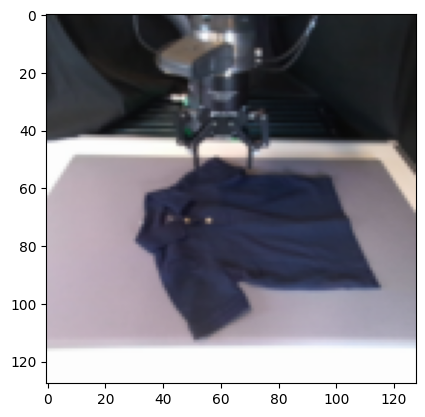

In [9]:
import h5py
import matplotlib.pyplot as plt

# real_robot_path = "/home/mbronars/zhenyang/demos/pick_cube_osc_franka_80hz_seq.hdf5"
# real_robot_path = "/home/mbronars/zhenyang/demos/test_1218.hdf5"
real_robot_path = "/home/mbronars/zhenyang/demos/speed_stacking_agentview_0116/with_agentview_demo.hdf5"
real_robot_path = "/home/mbronars/zhenyang/demos/oven_bowl_50_demos_0117/with_agentview_demo.hdf5"
# real_robot_path = "/home/mbronars/zhenyang/demos/wiping_board_rightwrist_30_0118/single-line-right-wrist_demo.hdf5"

# real_robot_path = "/home/mbronars/zhenyang/demos/speed_stacking_52_0118/stacking_only.hdf5"
# real_robot_path = "/home/mbronars/zhenyang/demos/speed_stacking_52_0118/with_agentview_demo.hdf5"

num_samples = []

real_robot_path = "/srv/rl2-lab/flash7/zhenyang/data/speed_stacking_52_stacking_only_0120.hdf5"
real_robot_path = "/srv/rl2-lab/flash7/zhenyang/data/folding_0130.hdf5"
# real_robot_path = "/srv/rl2-lab/flash7/zhenyang/data/oven_bowl_50demos_0120.hdf5"

# real_robot_path = "/srv/rl2-lab/flash7/zhenyang/data/wiping_board_rightwrist_30_0118.hdf5"

demo_num = 3
len_list = []
# for demo_num in range(50):
    
with h5py.File(real_robot_path, 'r') as f:
    print(f"demo: {f['data'].keys()}")
    # print(f"demo attr {f['data'].attrs['env_args']}")
    print(f"demo keys {f['data/demo_1'].keys()}")
    images_obs = f['data'][f'demo_{demo_num}']['obs']['agentview_image'][...]
    # states = f['data']['demo_0']['states'][...] # low dim simulation states
    states = f['data'][f'demo_{demo_num}']['obs']['eef_pose'][...]
    # actions = f['data']['demo_0']['actions'][...]
    # abs_actions = f['data'][f'demo_{demo_num}']['absolute_reached_actions_with_precision'][...]
    # abs_actions = f['data'][f'demo_{demo_num}']['consistent_absolute_reached_actions_eefpose_shift_precision'][...]
    # abs_actions = f['data'][f'demo_{demo_num}']['consistent_absolute_reached_actions_eefpose_shift'][...]
    # joint_actions = f['data'][f'demo_{demo_num}']['abs_joint_reached_actions_with_precision'][...]

    actions = f['data'][f'demo_{demo_num}']['consistent_absolute_reached_actions_eefpose_shift'][...]
    # print(f"abs action {abs_actions.shape}")
    # len_list.append(abs_actions.shape[0])

    # joint_actions = f['data'][f'demo_{demo_num}']['obs/joint_position'][...]
    # joint_positions = f['data'][f'demo_{demo_num}']['obs/joint_positions'][...]

# print(f"shape of joint actions {joint_actions.shape}")
# print(f"shape of joint positions {joint_positions.shape}")
# joint_diff = joint_actions - joint_positions
# print(f"if any joint diff is not zero, then the joint position is not the same as the joint action")
# print(f"joint diff {joint_diff}")

# print(f"joint actions {joint_actions[:5,:]}")


# plt.plot(abs_actions[:, 3:6])
# plt.show()
# plt.savefig(f"/srv/rl2-lab/flash7/zhenyang/data/test/demo_{demo_num}.png")

print(images_obs.shape)
# print(f"abs action {abs_actions.shape}")
# print(abs_actions[-5:,:])
# print(states[-5:, :])
print(f"first element of the axis angle {actions[:, 3]}") # test axis angle consistency

# images_obs.swapaxes(1,3)  ``
plt.imshow(images_obs[20,...])
print(f"abs action {abs_actions.shape}")
# print(f"state {states}")

## Plotting reached pose vs commanded pose
Use stacking cups, because it involves more z axis motion

demo: <KeysViewHDF5 ['demo_0', 'demo_1', 'demo_10', 'demo_11', 'demo_12', 'demo_13', 'demo_14', 'demo_15', 'demo_16', 'demo_17', 'demo_18', 'demo_19', 'demo_2', 'demo_20', 'demo_21', 'demo_22', 'demo_23', 'demo_24', 'demo_25', 'demo_26', 'demo_27', 'demo_28', 'demo_29', 'demo_3', 'demo_30', 'demo_31', 'demo_32', 'demo_33', 'demo_34', 'demo_35', 'demo_36', 'demo_37', 'demo_38', 'demo_39', 'demo_4', 'demo_40', 'demo_41', 'demo_42', 'demo_43', 'demo_44', 'demo_45', 'demo_46', 'demo_47', 'demo_48', 'demo_49', 'demo_5', 'demo_6', 'demo_7', 'demo_8', 'demo_9']>
demo keys <KeysViewHDF5 ['abs_reached_actions_joint_pos_shift_precision', 'absolute_actions', 'absolute_commanded_actions_with_precision', 'absolute_reached_actions_eefpose_shift_precision', 'absolute_reached_actions_with_precision', 'actions', 'control_enabled', 'delta_actions', 'dones', 'obs', 'precisions', 'rewards', 'waypoints_dp', 'waypoints_dp0.02', 'waypoints_dp0.03', 'waypoints_dp0.04', 'waypoints_dp0.05']>
demo keys <KeysView

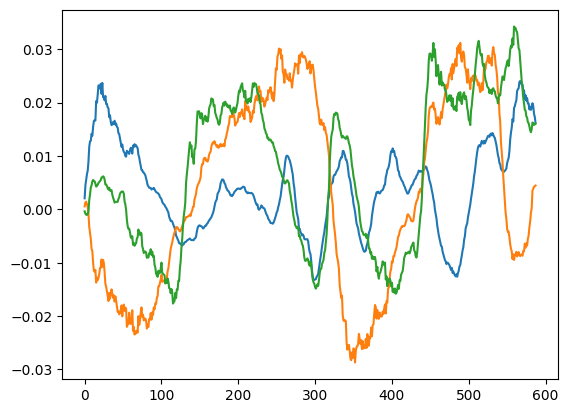

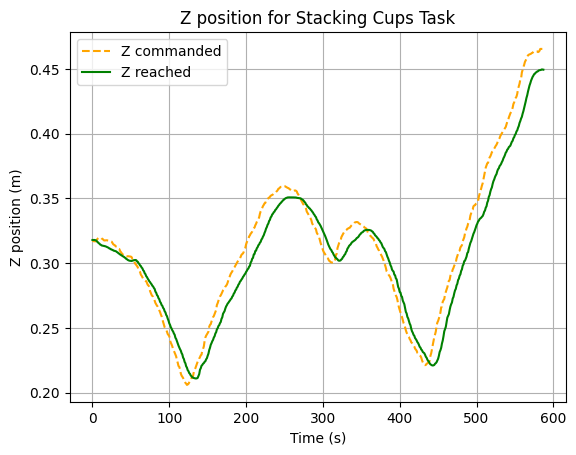

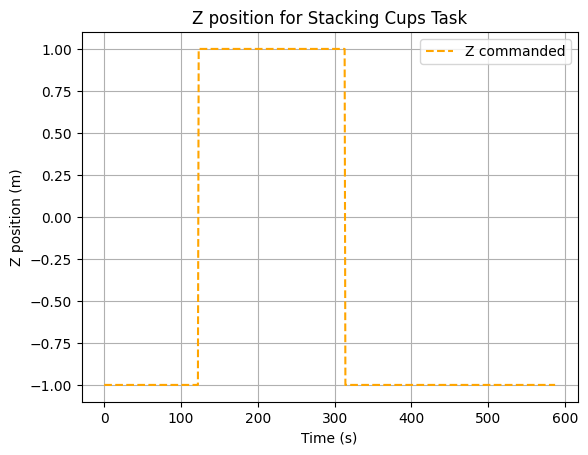

In [71]:
import h5py
import matplotlib.pyplot as plt
import numpy as np

real_robot_path = "/home/mbronars/zhenyang/demos/speed_stacking_agentview_0116/with_agentview_demo.hdf5"
real_robot_path = "/home/mbronars/zhenyang/demos/speed_stacking_52_0118/stacking_only.hdf5"
real_robot_path = "/home/mbronars/zhenyang/demos/oven_bowl_50_demos_0117/with_agentview_demo.hdf5"

demo_num = 15
with h5py.File(real_robot_path, 'r') as f:
    print(f"demo: {f['data'].keys()}")
    print(f"demo keys {f['data/demo_1'].keys()}")
    print(f"demo keys {f['data/demo_1/obs'].keys()}")
    images_obs = f['data'][f'demo_{demo_num}']['obs']['agentview_image'][...]
    # states = f['data']['demo_0']['states'][...] # low dim simulation states
    states = f['data'][f'demo_{demo_num}']['obs']['eef_pose'][...]
    abs_actions = f['data'][f'demo_{demo_num}']['absolute_commanded_actions_with_precision'][...]

    abs_joint_pos = f['data'][f'demo_{demo_num}']['abs_reached_actions_joint_pos_shift_precision'][...]


print(abs_joint_pos[1:7,:])

difference = abs_actions[:, :3] - states[:, :3]
ratio = abs_actions[:, :3] / states[:, :3]

awe_label = abs_actions[:, -1]
print(f"ratio is {np.mean(np.abs(ratio), axis=0)}")
print(np.mean(np.abs(difference), axis=0))
# plt.plot(difference)

fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(abs_actions[:, 2], 'orange', linestyle='--', label='Z commanded')
ax.plot(states[:, 2], 'green', linestyle='-', label='Z reached')
ax.plot(awe_label*0.4, 'blue', linestyle='-', label='AWE label')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Z position (m)')
ax.set_title('Z position for Stacking Cups Task')
ax.grid(True)
ax.legend()
plt.show()

fig2 = plt.figure()
ax2 = fig2.add_subplot(111)
ax2.plot(abs_actions[:, 6], 'orange', linestyle='--', label='Gripper action')
ax2.plot(awe_label, 'blue', linestyle='-', label='AWE label')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Z position (m)')
ax2.set_title('Z position for Stacking Cups Task')
ax2.grid(True)
ax2.legend()
plt.show()

## Data fix for stacking
Detect where the gripper is open and close


In [32]:
import numpy as np

def detect_gripper_transition(abs_actions):
    gripper_data = abs_actions[:, 6]

    prev_state = -1
    transition_indices = [] # from close to open
    for i in range(len(gripper_data)):
        curr_state = gripper_data[i]
        if prev_state >= 0.9 and curr_state <=   -0.9:
            transition_indices.append(i)
        prev_state = curr_state

    print(transition_indices)
    return transition_indices[1]

detect_gripper_transition(abs_actions)

tt = np.array([1,2,3])
ori = np.array([5,5,5])

print(tt*ori)


[253, 448, 567]
[ 5 10 15]


## Get dataset for plotting
Get certain demos with certain keys and save to specific path

In [6]:
import os
import h5py
import numpy as np

# dataset = "/home/mbronars/zhenyang/demos/oven_bowl_50_demos_0117/with_agentview_demo.hdf5"
# save_name = "0126_for_plotting_awe_label.hdf5"

dataset = "/home/mbronars/zhenyang/demos/speed_stacking_52_0118/stacking_only.hdf5"
save_name = "0126_for_plotting_awe_label.hdf5"
num_demos = 6
err_threshold = 0.05

f = h5py.File(dataset, "r+")

demos = list(f["data"].keys())
inds = np.argsort([int(elem[5:]) for elem in demos])
demos = [demos[i] for i in inds]
demos = [demos[i] for i in range(num_demos)]

with h5py.File(f"{os.path.dirname(dataset)}/{save_name}", "w") as new_f:

    for i in range(len(demos)):
        ep = demos[i]

        # if "waypoints_dp0.05" not in f[f"data/{ep}"]:
        #     continue
    
        absolute_actions = f[f"data/{ep}/absolute_actions"][()]
        absolute_commanded_actions_with_precision = f[f"data/{ep}/absolute_commanded_actions_with_precision"][()]
        absolute_reached_actions_eefpose_shift_precision = f[f"data/{ep}/absolute_reached_actions_eefpose_shift_precision"][()]
        # if err_threshold is not None:
        #     waypoints = f[f"data/{ep}/waypoints_dp{str(err_threshold)}"][()]
        # else:
        #     waypoints = f[f"data/{ep}/waypoints_dp"][()]

        # transition_index = detect_gripper_transition(absolute_actions)
        # transition_index += 10           
        
        ### Trim the absolute actions
        # absolute_actions_trimmed = absolute_actions[:transition_index]
        # absolute_commanded_actions_with_precision_trimmed = absolute_commanded_actions_with_precision[:transition_index]
        # absolute_reached_actions_eefpose_shift_precision_trimmed = absolute_reached_actions_eefpose_shift_precision[:transition_index]

        # Create a new dataset to save the trimmed data
        grp = new_f.create_group(f"data/{ep}")
        # Save the trimmed observations
        obs_grp = grp.create_group("obs")
        for obs_key in f[f"data/{ep}/obs"].keys():
            if "image" in obs_key:
                continue
            # obs_grp.create_dataset(obs_key, data=f[f"data/{ep}/obs"][obs_key][:transition_index])
            obs_grp.create_dataset(obs_key, data=f[f"data/{ep}/obs"][obs_key])
        
        # Save the trimmed absolute actions
        # grp.create_dataset("absolute_actions", data=absolute_actions_trimmed)
        # grp.create_dataset("absolute_commanded_actions_with_precision", data=absolute_commanded_actions_with_precision_trimmed)
        # grp.create_dataset("absolute_reached_actions_eefpose_shift_precision", data=absolute_reached_actions_eefpose_shift_precision_trimmed)
        grp.create_dataset("absolute_actions", data=absolute_actions)
        grp.create_dataset("absolute_commanded_actions_with_precision", data=absolute_commanded_actions_with_precision)
        grp.create_dataset("absolute_reached_actions_eefpose_shift_precision", data=absolute_reached_actions_eefpose_shift_precision)

        key_list = f[f"data/{ep}"].keys()
        for key in key_list:
            if "waypoints" in key:
                # get all the keys containing waypoints (dp0.05, dp0.01, etc)
                waypoints = f[f"data/{ep}/{key}"][()]
                grp.create_dataset(key, data=waypoints)

In [106]:
tt = np.array([42, 33.88, 26])

tt/13

array([3.23076923, 2.60615385, 2.        ])

0126 Quick check for the predicted waypoints of new action scheduling env


Demo avr time: 33.88s
acc time for reached model:
[42, 23, 14, 11]
time for desired model: 26s

TODO:
1. calculate tracking error.
2. Need large scale testing

True
<KeysViewHDF5 ['demo_0']>
<KeysViewHDF5 ['action_timestamps', 'actions', 'inference_action_seq', 'inference_t', 'obs', 'rewards', 'states']>
eef pose shape (99, 2, 6)
obs timestamp shape (99, 2)
(10, 28)
(10, 28, 14)


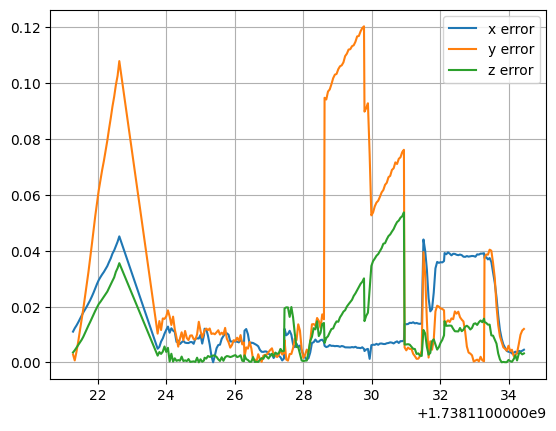

xyz error is [0.01447197 0.02984864 0.01161118]


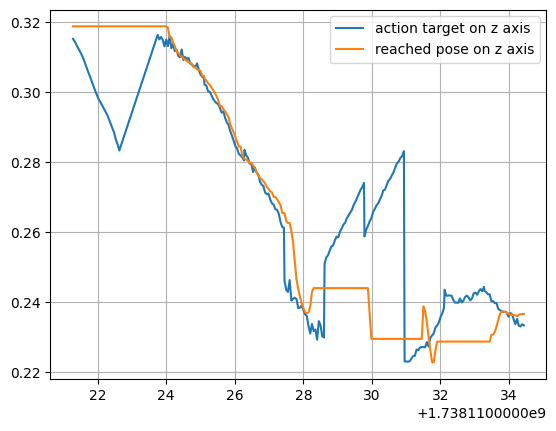

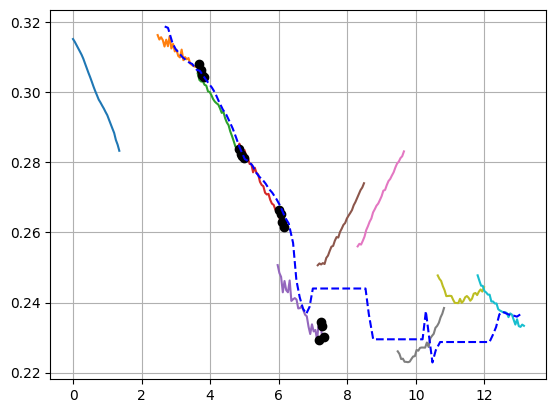

In [105]:
import matplotlib.pyplot as plt

# dataset = "/home/mbronars/zhenyang/rollout_data/0127_owen_action_scheduling_80hz.hdf5"
# dataset = "/home/mbronars/zhenyang/rollout_data/0128_owen_action_scheduling_20hz_inpaint.hdf5"
dataset = "/home/mbronars/zhenyang/rollout_data/0128_owen_action_scheduling_cond_20hz.hdf5"

# quick testing for the action condition inpu
array1 = np.array([
    [0.475118, 0.001083, 0.308215, -0.086363, -1.000001, 0.00605],
    [0.476397, -0.005126, 0.306391, -0.086444, -0.991524, 0.003396],
    [0.479401, -0.00445, 0.305017, -0.092961, -0.995019, 0.004178],
    [0.480109, -0.008802, 0.304415, -0.087541, -1.000001, 0.001814]
])

array2 = np.array([
    [4.993954e-01, -5.969255e-02, 2.839418e-01, 1.022911e-01, -1.000001e+00, 9.956967e-04],
    [5.007973e-01, -6.069022e-02, 2.823282e-01, 1.040634e-01, -1.000001e+00, 2.371522e-03],
    [5.022001e-01, -6.270499e-02, 2.818997e-01, 1.066810e-01, -1.000001e+00, -5.364418e-07],
    [5.038933e-01, -6.367657e-02, 2.813506e-01, 1.047189e-01, -1.000001e+00, 1.553835e-03]
])

array3 = np.array([
    [0.5206, -0.07332, 0.266397, 0.140137, -0.945301, 0.013852],
    [0.520978, -0.074303, 0.265276, 0.139879, -0.938246, 0.017227],
    [0.5209, -0.07663, 0.262923, 0.139094, -0.94162, 0.009837],
    [0.520455, -0.076088, 0.261452, 0.144341, -0.943672, 0.014019]
])

array4 = np.array([
    [0.53268, -0.070276, 0.229278, 0.128733, -0.894068, 0.98989],
    [0.532734, -0.071323, 0.234572, 0.12581, -0.854527, 0.991037],
    [0.533283, -0.073836, 0.233408, 0.130229, -0.734762, 0.989795],
    [0.533428, -0.068968, 0.230247, 0.141562, -0.595795, 0.997295]
])

array5 = np.array([
    [0.530529, 0.030355, 0.269847, 0.055434, -0.982356, 0.996027],
    [0.53052, 0.030525, 0.270982, 0.054019, -0.985209, 0.99865],
    [0.53041, 0.032178, 0.272114, 0.053904, -0.982343, 0.997998],
    [0.53072, 0.033345, 0.272852, 0.053155, -0.982723, 0.997207]
])

action_dim = 2

tt_list = []
print(tt_list is not None)

with h5py.File(dataset, "r") as f:
    print(f["data"].keys())
    print(f["data/demo_0"].keys())
    
    action_timestamps = f["data/demo_0/action_timestamps"][()]
    actions = f["data/demo_0/actions"][()] # time x predicted_action_length x action_dim
    eef_pose = f["data/demo_0/obs/eef_pose"][()]
    obs_timestamp = f["data/demo_0/obs/timestamp"][()]
    print(f"eef pose shape {eef_pose.shape}")
    print(f"obs timestamp shape {obs_timestamp.shape}")
    print(action_timestamps.shape)
    print(actions.shape)

    ###### get tracking error ######
    t_now = 0.0
    action_timestamp_flat = np.reshape(action_timestamps, (-1)) # [t, act sequence] -> [1, t xlen] 
    action_flat = np.reshape(actions, (-1, actions.shape[-1])) 
    eef_pose_flat = np.reshape(eef_pose, (-1, eef_pose.shape[-1])) # [txlen, act_dim]
    eef_pose_timestamp_flat = np.reshape(obs_timestamp, (-1))
    
    # get rid of the repeat timestampes
    act_list = []
    act_t_list = []
    eef_pose_list = []
    for act, t_act in zip(action_flat, action_timestamp_flat):
        if t_act > t_now:
            t_now = t_act
            act_t_list.append(t_now)
            act_list.append(act)

            # find closet obs timestamp to given act timestamp
            t_obs_closest_id = np.argmin(np.abs(eef_pose_timestamp_flat-t_now))
            eef_pose_list.append(eef_pose_flat[t_obs_closest_id, :])

    act_list_np = np.array(act_list)
    eef_pose_list_np = np.array(eef_pose_list)
    xyz_error = np.abs(act_list_np[:, :3] - eef_pose_list_np[:, :3])
    plt.plot(act_t_list, xyz_error[:, 0], label='x error')
    plt.plot(act_t_list, xyz_error[:, 1], label='y error')
    plt.plot(act_t_list, xyz_error[:, 2], label='z error')
    plt.legend()
    plt.grid()
    plt.show()
    print(f"xyz error is {np.mean(xyz_error, axis=0)}")
    plt.plot(act_t_list, act_list_np[:, 2], label='action target on z axis')
    plt.plot(act_t_list, eef_pose_list_np[:, 2], label='reached pose on z axis')
    plt.legend()
    plt.grid()
    plt.show()
    ###### get tracking error ######

    # position_error = eef_pose[:, -1, :3]

    t_start = action_timestamps[0, 0]
    time_length = actions.shape[0]
    for i in range(time_length):
        plt.plot(action_timestamps[i]-t_start, actions[i, :, action_dim])

    plt.plot(action_timestamps[1, -4:]-t_start, array1[:, action_dim], "ok")
    plt.plot(action_timestamps[2, -4:]-t_start, array2[:, action_dim], "ok")
    plt.plot(action_timestamps[3, -4:]-t_start, array3[:, action_dim], "ok")
    plt.plot(action_timestamps[4, -4:]-t_start, array4[:, action_dim], "ok")
    
    plt.plot(obs_timestamp[:,-1]-t_start, eef_pose[:, -1, action_dim], "--b")
    plt.grid()
    plt.show()

## TESTing random code

In [81]:
from bisect import bisect_left

def find_closest_numbers_indices(A, B):
    results = []
    for b in B:
        # Find the position to insert `b` in `A` using binary search
        pos = bisect_left(A, b)
        
        # Compare neighbors to find the closest element
        if pos == 0:  # `b` is smaller than or equal to the smallest element in `A`
            closest_index = 0
        elif pos == len(A):  # `b` is greater than the largest element in `A`
            closest_index = len(A) - 1
        else:
            # Check the nearest two elements
            left = A[pos - 1]
            right = A[pos]
            closest_index = pos - 1 if abs(left - b) <= abs(right - b) else pos
        
        # Store the result
        results.append((A[closest_index], closest_index))
    
    return results

# Example usage
A = [1, 2, 2, 3, 3, 5, 5, 7, 7, 8, 9]
B = [2.5, 3.5, 6, 7]
bb = np.arange(7-3, 7, 0.5)
bb = np.linspace(4, 7, num=6, endpoint=True)
print(bb)
result = find_closest_numbers_indices(A, B)
print(result)

[4.  4.6 5.2 5.8 6.4 7. ]
[(2, 2), (3, 4), (5, 6), (7, 7)]


## Throughput Calculation
Calculate the throughput with different metrics

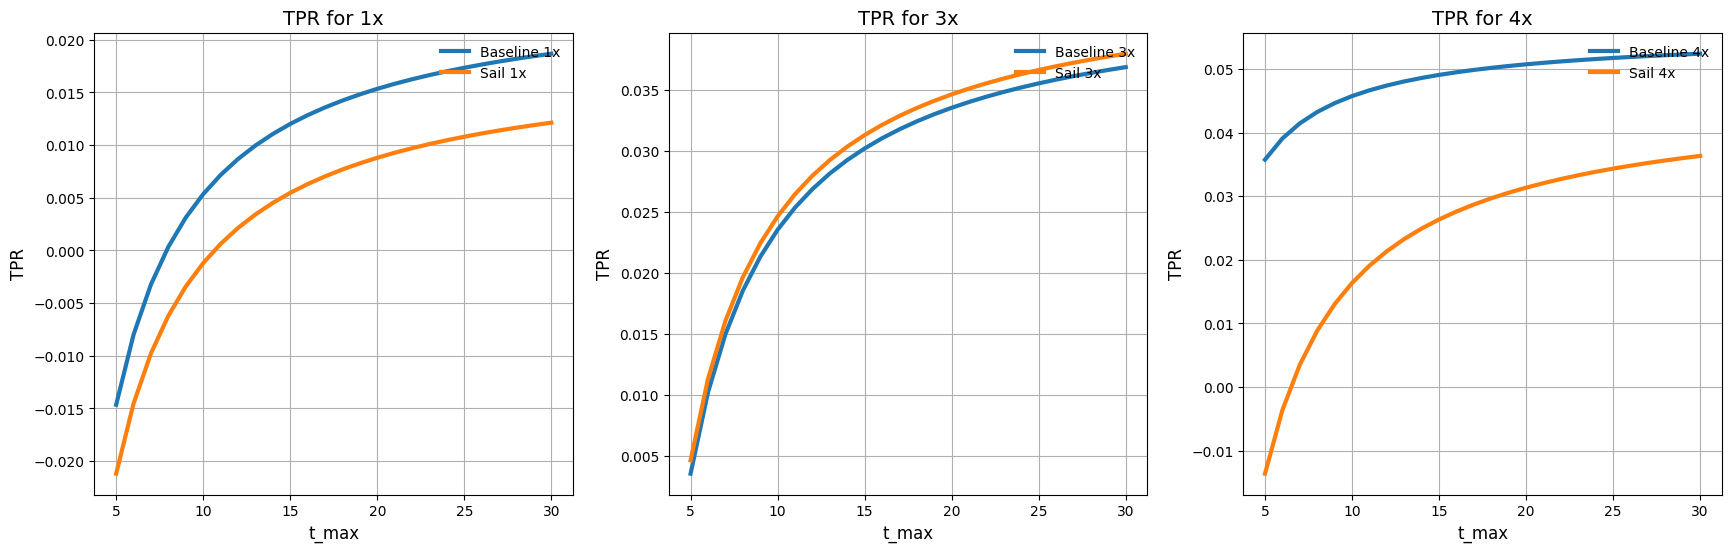

In [22]:
import numpy as np

# Example usage:
# success = np.array([1, 1, 0, 1])  # 3 successes, 1 failure
# times = np.array([10.0, 12.0, 0.0, 15.0])  # Execution times (0 for failure)
# tpr = calculate_tpr(success, times)

import matplotlib.pyplot as plt

t_max_range = range(5, 31)
tpr_results = {speed_exp: {speed: [] for speed in oven_task[speed_exp].keys()} for speed_exp in oven_task.keys()}

for t_max in t_max_range:
    for speed_exp in oven_task.keys():
        for speed in oven_task[speed_exp].keys():
            success = oven_task[speed_exp][speed]['success']
            time = oven_task[speed_exp][speed]['time']
            tpr = calculate_tpr(success, time, t_max)
            tpr_results[speed_exp][speed].append(tpr)

# Plotting
fig, axs = plt.subplots(1, 3, figsize=(21, 6))

# Plot for 1x
axs[0].plot(t_max_range, tpr_results['baseline']['1x'], label='Baseline 1x', linewidth=3)
axs[0].plot(t_max_range, tpr_results['sail']['1x'], label='Sail 1x', linewidth=3)
axs[0].set_title('TPR for 1x', fontsize=14)
axs[0].set_xlabel('t_max', fontsize=12)
axs[0].set_ylabel('TPR', fontsize=12)
axs[0].legend(loc='upper right', fontsize=10, frameon=False)
axs[0].grid(True)

# Plot for 3x
axs[1].plot(t_max_range, tpr_results['baseline']['3x'], label='Baseline 3x', linewidth=3)
axs[1].plot(t_max_range, tpr_results['sail']['3x'], label='Sail 3x', linewidth=3)
axs[1].set_title('TPR for 3x', fontsize=14)
axs[1].set_xlabel('t_max', fontsize=12)
axs[1].set_ylabel('TPR', fontsize=12)
axs[1].legend(loc='upper right', fontsize=10, frameon=False)
axs[1].grid(True)

# Plot for 4x
axs[2].plot(t_max_range, tpr_results['baseline']['4x'], label='Baseline 4x', linewidth=3)
axs[2].plot(t_max_range, tpr_results['sail']['4x'], label='Sail 4x', linewidth=3)
axs[2].set_title('TPR for 4x', fontsize=14)
axs[2].set_xlabel('t_max', fontsize=12)
axs[2].set_ylabel('TPR', fontsize=12)
axs[2].legend(loc='upper right', fontsize=10, frameon=False)
axs[2].grid(True)

plt.show()


In [78]:
stacking_cup = {"sail": {"1x": {"success": np.array([1, 1, 1, 1, 1, 1, 0, 1, 1, 1]),
                        "time": np.array([33.25, 36.47, 31.72, 27.0, 33.92, 28.28, 0.0, 30.62, 29.28, 29.55])},
                "4x": {"success":np.array([1, 0, 0, 0, 1, 0, 1, 1, 0, 0]),
                       "time": np.array([19.1, 0.0, 0.0, 0.0, 12.93, 0.0, 12.91, 13.88, 0.0, 0.0])}},

                       "baseline": {"1x": {"success":  np.array([0, 1, 1, 0, 0, 0, 1, 0, 0, 0]),
                       "time": np.array([0.0, 28.58, 32.42, 0.0, 0.0, 0.0, 35.42, 0.0, 0.0, 0.0])},
                       "4x": {"success":np.array([0, 0, 1, 0, 0, 0, 0, 0, 0, 0]),
                       "time":np.array([0.0, 0.0, 14.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])}}}

wiping_board = {"sail": {"1x": {"success": np.array([1, 1, 0, 1, 1, 1, 1, 1, 1, 1]),
                        "time": np.array([43.43, 45.7, 0.0, 40.4, 38.52, 47.57, 40.37, 43.4, 51.89, 40.33])},
                "4x": {"success": np.array([0, 1, 1, 0, 1, 1, 0, 1, 1, 1]),
                       "time": np.array([0.0, 9.95, 13.1, 11.58, 9.31, 11.6, 11.6, 9.53, 9.66, 9.95])}},
                "baseline": {"1x": {"success": np.array([1, 1, 0, 1, 1, 1, 1, 1, 1, 1]),
                       "time": np.array([28.37, 28.34, 0.0, 26.59, 31.67, 26.77, 28.8, 26.3, 25.73, 27.87])},
                       "4x": {"success": np.array([0, 1, 1, 1, 1, 1, 1, 1, 1, 1]),
                       "time": np.array([0.0, 13.76, 13.03, 13.41, 17.91, 15.13, 13.65, 17.08, 14.71, 12.21])}}}

oven_task = {"sail": {'1x': {'success': np.array([1, 1, 0, 1, 1, 0, 1, 1, 1, 1]),
                                                        'time': np.array([40.0, 53.57, 60.0, 41.0, 41.87, 60.0, 42.17, 40.97, 42.24, 41.2])},
                                                    '3x': {'success': np.array([1, 0, 1, 1, 1, 1, 1, 1, 0, 1]),
                                                           'time': np.array([18.0, 18.99, 19.79, 18.3, 20.76, 15.03, 16.57, 17.29, 11.0, 18.88])},
                                                    '4x': {'success': np.array([1, 1, 0, 1, 0, 1, 1, 1, 1, 0]),
                                                        'time': np.array([15.8, 13.93, 13.08, 15.99, 15.74, 15.49, 15.07, 14.82, 14.79, np.inf])}},
                             "baseline": {'1x': {'success': np.array([1, 1, 0, 0, 1, 1, 1, 1, 1, 1]),
                                                 'time': np.array([32.85, 31.63, 40.0, 40.0, 30.78, 31.92, 30.68, 31.6, 31.34, 31.79])},
                                          '3x': {'success': np.array([1, 1, 1, 1, 0, 0, 1, 1, 1, 1]),
                                                 'time': np.array([17.26, 19.77, 18.8, 18.35, 19.0, 21.0, 18.16, 19.04, 18.28, 17.51])},
                                          '4x': {'success': np.array([1, 1, 0, 1, 1, 1, 1, 1, 1, 1]),
                                                 'time': np.array([16.04, 16.44, 15.0, 15.74, 16.73, 17.02, 15.64, 15.99, 16.31, 15.46])}}
}

folding_CFG = {"sail": {"1x": {"success": np.array([0, 0, 0, 0, 0, 1, 0, 0, 0, 1]),
                        "time": np.array([0, 0, 0, 0, 0, 33.28, 0, 0, 0, 33.35]) },
                "4x": {"success":np.array([0, 0, 0, 0, 1, 1, 0, 1, 0, 0]),
                       "time": np.array([0, 0, 0, 0, 13.05, 13.56, 0, 14.43, 0, 0])}},
                "baseline": {"1x": {"success": np.array([0, 1, 0, 0, 1, 0, 0, 0, 0, 0]),
                       "time": np.array([0, 27.35, 0, 0, 27.35, 0, 0, 0, 0, 0]) },
                       "4x": {"success": np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 1]),
                       "time":np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 14.6])}}}

oven_CFG = {"sail": {"1x": {"success": np.array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1]) ,
                        "time":np.array([44.32, 49.57, 45.54, 59.0, 50.05, 48.74, 53.58, 50.1, 45.19, 48.56]) },
                "4x": {"success":np.array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1]) ,
                       "time": np.array([15.7, 15.89, 13.88, 11.55, 15.33, 14.9, 14.11, 14.4, 14.2, 13.98])}},
                "baseline": {'1x': {'success': np.array([1, 1, 0, 0, 1, 1, 1, 1, 1, 1]),
                                                 'time': np.array([32.85, 31.63, 40.0, 40.0, 30.78, 31.92, 30.68, 31.6, 31.34, 31.79])},
                            '3x': {'success': np.array([1, 1, 1, 1, 0, 0, 1, 1, 1, 1]),
                                                 'time': np.array([17.26, 19.77, 18.8, 18.35, 19.0, 21.0, 18.16, 19.04, 18.28, 17.51])},
                           '4x': {'success': np.array([1, 1, 0, 1, 1, 1, 1, 1, 1, 1]),
                                                 'time': np.array([16.04, 16.44, 15.0, 15.74, 16.73, 17.02, 15.64, 15.99, 16.31, 15.46])}}}


demo_time = {"stacking_cup": 25.89, "wiping_board": 34.03, "oven_task": 36.522, "folding_cloth": 30.43}


## Throughput Calculation for Stacking Cup

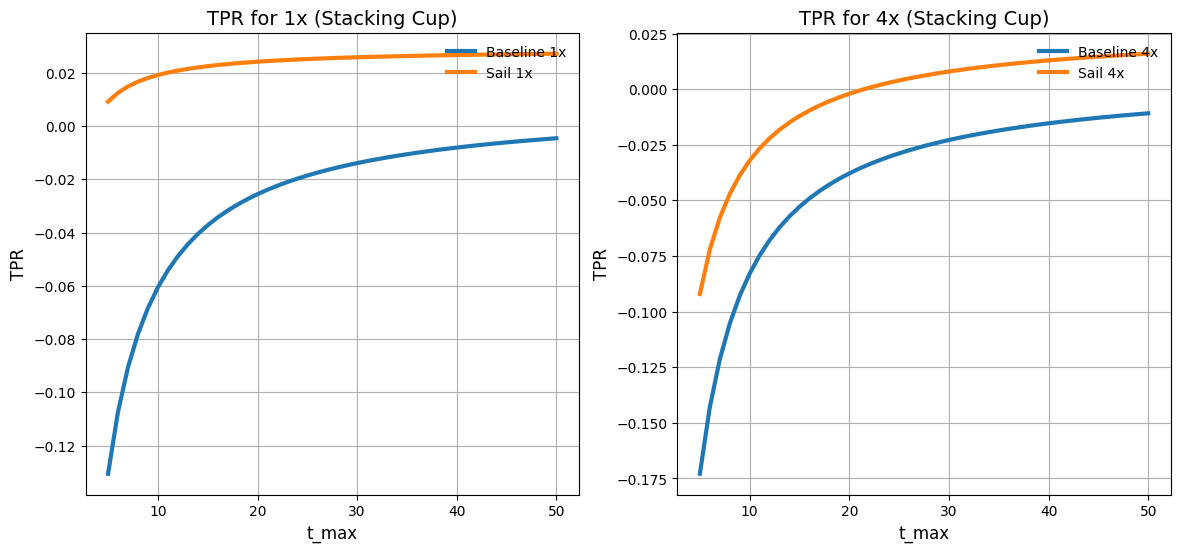

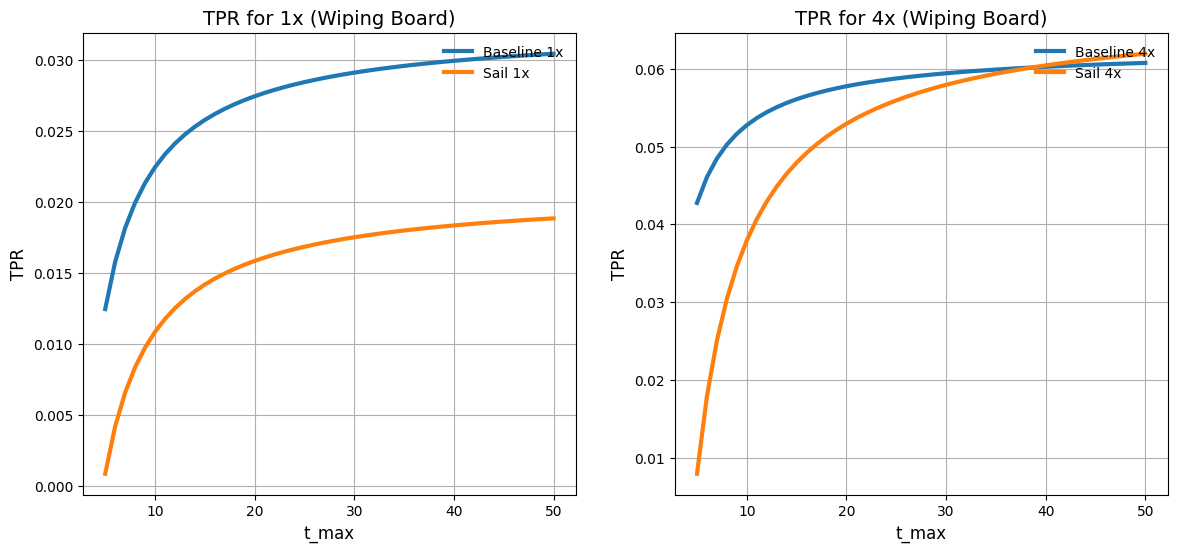

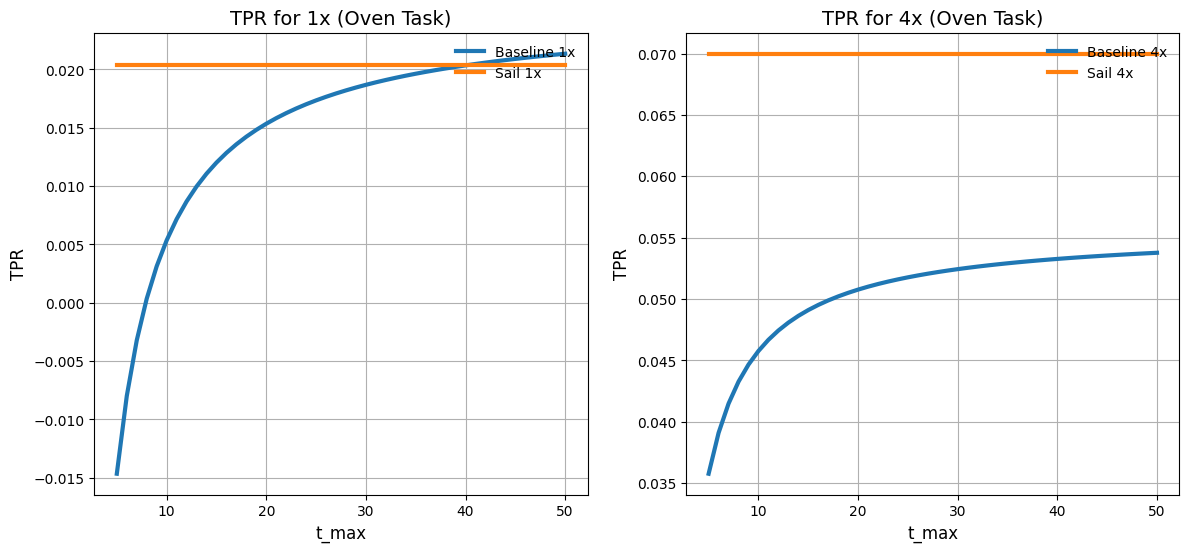

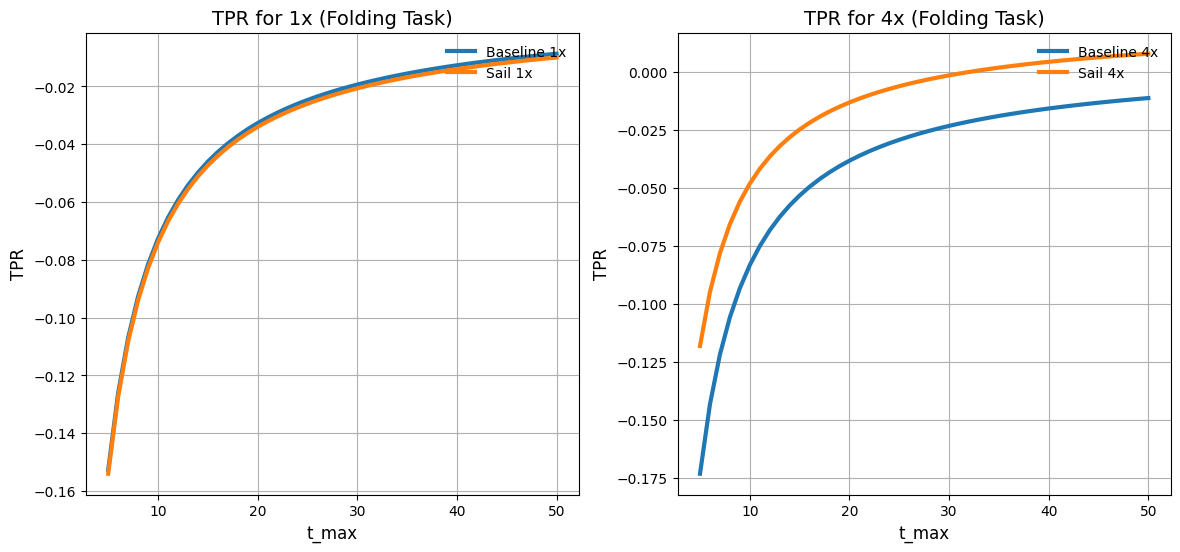

Task: Stacking Cup
Baseline 4x TPR: -0.03785714285714285
Sail 4x TPR: -0.0020799015202803374

Task: Wiping Board
Baseline 4x TPR: 0.05776093172827486
Sail 4x TPR: 0.05294106482175652

Task: Oven Task
Baseline 4x TPR: 0.050770389885928593
Sail 4x TPR: 0.06998682517629183

Task: Folding Task
Baseline 4x TPR: -0.03815068493150685
Sail 4x TPR: -0.013032526552514351



In [38]:

def calculate_tpr(success_array, time_array, t_max):
    """
    Calculate Throughput Performance Regret (TPR)
    
    Args:
        success_array (np.ndarray): Array of binary values (1 for success, 0 for failure)
        time_array (np.ndarray): Array of execution times for successful attempts
        t_max: time allowed for each trial
        
    Returns:
        float: TPR value
    """
    N = len(success_array)
    
    tpr = 0.0
    for i in range(N):
        if success_array[i]:  # If successful
            tpr += (1.0 / time_array[i]) * success_array[i]
        tpr -= (1.0 / t_max) * (1 - success_array[i])
    
    return tpr / N

def calculate_and_plot_tpr(data_dict, title_suffix):
    # Calculate TPR for given data
    t_max_range = np.arange(5, 51, 1)
    tpr_results = {'sail': {'1x': [], '4x': []}, 'baseline': {'1x': [], '4x': []}}

    for t_max in t_max_range:
        for speed_exp in tpr_results.keys():
            for speed in tpr_results[speed_exp].keys():
                success = data_dict[speed_exp][speed]['success']
                time = data_dict[speed_exp][speed]['time']
                tpr = calculate_tpr(success, time, t_max)
                tpr_results[speed_exp][speed].append(tpr)

    # Plotting for given data
    fig, axs = plt.subplots(1, 2, figsize=(14, 6))

    # Plot for 1x
    axs[0].plot(t_max_range, tpr_results['baseline']['1x'], label='Baseline 1x', linewidth=3)
    axs[0].plot(t_max_range, tpr_results['sail']['1x'], label='Sail 1x', linewidth=3)
    axs[0].set_title(f'TPR for 1x ({title_suffix})', fontsize=14)
    axs[0].set_xlabel('t_max', fontsize=12)
    axs[0].set_ylabel('TPR', fontsize=12)
    axs[0].legend(loc='upper right', fontsize=10, frameon=False)
    axs[0].grid(True)

    # Plot for 4x
    axs[1].plot(t_max_range, tpr_results['baseline']['4x'], label='Baseline 4x', linewidth=3)
    axs[1].plot(t_max_range, tpr_results['sail']['4x'], label='Sail 4x', linewidth=3)
    axs[1].set_title(f'TPR for 4x ({title_suffix})', fontsize=14)
    axs[1].set_xlabel('t_max', fontsize=12)
    axs[1].set_ylabel('TPR', fontsize=12)
    axs[1].legend(loc='upper right', fontsize=10, frameon=False)
    axs[1].grid(True)

    plt.show()

# Example usage
calculate_and_plot_tpr(stacking_cup, "Stacking Cup")
calculate_and_plot_tpr(wiping_board, "Wiping Board")

# Calculate TPR for CFG dict
calculate_and_plot_tpr(oven_CFG, "Oven Task")
calculate_and_plot_tpr(folding_CFG, "Folding Task")



Task: Stacking Cups
Baseline 4x TPR: -0.04
Sail 4x TPR: -0.00
Improvement: 0.04
Improvement Percentage: -94.51%

Task: Wiping Board
Baseline 4x TPR: 0.06
Sail 4x TPR: 0.05
Improvement: -0.00
Improvement Percentage: -8.34%

Task: Baking
Baseline 4x TPR: 0.05
Sail 4x TPR: 0.07
Improvement: 0.02
Improvement Percentage: 37.85%

Task: Folding Cloth
Baseline 4x TPR: -0.04
Sail 4x TPR: -0.01
Improvement: 0.03
Improvement Percentage: -65.84%

Task: Stacking Cups
Baseline 4x Success Rate: 0.10
Baseline 4x Average Time for Successful Demos: 14.00
Sail 4x Success Rate: 0.40
Sail 4x Average Time for Successful Demos: 14.71
Baseline Time Ratio: 1.85
Sail Time Ratio: 1.76

Task: Wiping Board
Baseline 4x Success Rate: 0.90
Baseline 4x Average Time for Successful Demos: 14.54
Sail 4x Success Rate: 0.70
Sail 4x Average Time for Successful Demos: 10.44
Baseline Time Ratio: 2.34
Sail Time Ratio: 3.26

Task: Baking
Baseline 4x Success Rate: 0.90
Baseline 4x Average Time for Successful Demos: 16.15
Sail 4x

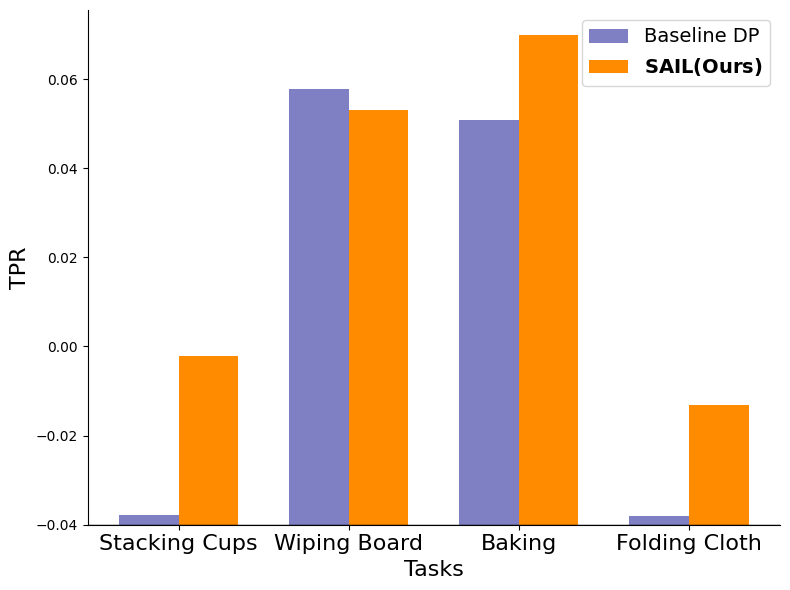

In [82]:
# Get TPR for 4x speed of baseline and sail for the above 4 tasks, using t_max=20
t_max = 20

tasks = {
    "Stacking Cups": stacking_cup,
    "Wiping Board": wiping_board,
    "Baking": oven_CFG,
    "Folding Cloth": folding_CFG
}

tpr_4x_results = {}

for task_name, data_dict in tasks.items():
    tpr_4x_results[task_name] = {
        "baseline_4x": calculate_tpr(data_dict['baseline']['4x']['success'], data_dict['baseline']['4x']['time'], t_max),
        "sail_4x": calculate_tpr(data_dict['sail']['4x']['success'], data_dict['sail']['4x']['time'], t_max)
    }

total_improvement = 0
for task_name, results in tpr_4x_results.items():
    baseline_tpr = results['baseline_4x']
    sail_tpr = results['sail_4x']
    improvement = sail_tpr - baseline_tpr
    improvement_percentage = (improvement / baseline_tpr) * 100
    total_improvement += improvement_percentage
    print(f"Task: {task_name}")
    print(f"Baseline 4x TPR: {baseline_tpr:.2f}")
    print(f"Sail 4x TPR: {sail_tpr:.2f}")
    print(f"Improvement: {improvement:.2f}")
    print(f"Improvement Percentage: {improvement_percentage:.2f}%")
    print()

for task_name, data_dict in tasks.items():
    baseline_success_rate = np.mean(data_dict['baseline']['4x']['success'])
    baseline_avg_time = np.mean([time for success, time in zip(data_dict['baseline']['4x']['success'], data_dict['baseline']['4x']['time']) if success])
    
    sail_success_rate = np.mean(data_dict['sail']['4x']['success'])
    sail_avg_time = np.mean([time for success, time in zip(data_dict['sail']['4x']['success'], data_dict['sail']['4x']['time']) if success])
    
    demo_time_mapping = {
        "Stacking Cups": 25.89,
        "Wiping Board": 34.03,
        "Baking": 36.522,
        "Folding Cloth": 30.43
    }
    
    baseline_time_ratio = baseline_avg_time / demo_time_mapping[task_name]
    sail_time_ratio = sail_avg_time / demo_time_mapping[task_name]
    print(f"Task: {task_name}")
    print(f"Baseline 4x Success Rate: {baseline_success_rate:.2f}")
    print(f"Baseline 4x Average Time for Successful Demos: {baseline_avg_time:.2f}")
    print(f"Sail 4x Success Rate: {sail_success_rate:.2f}")
    print(f"Sail 4x Average Time for Successful Demos: {sail_avg_time:.2f}")
    print(f"Baseline Time Ratio: {1/baseline_time_ratio:.2f}")
    print(f"Sail Time Ratio: {1/sail_time_ratio:.2f}")

    print()


average_improvement = total_improvement / len(tpr_4x_results)
print(f"Average Improvement over Baseline: {average_improvement}")

import matplotlib.pyplot as plt
import numpy as np

# Prepare data for bar plot
tasks = ["Stacking Cups", "Wiping Board", "Baking", "Folding Cloth"]
baseline_4x_tpr = [tpr_4x_results[task]["baseline_4x"] for task in tasks]
sail_4x_tpr = [tpr_4x_results[task]["sail_4x"] for task in tasks]

x = np.arange(len(tasks))  # the label locations
width = 0.35  # the width of the bars

bottom = -0.04
fig, ax = plt.subplots(figsize=(8, 6))
rects1 = ax.bar(x - width/2, np.array(baseline_4x_tpr)-bottom, width, label='Baseline DP', color='darkblue', alpha=0.5, bottom=bottom)
rects2 = ax.bar(x + width/2, np.array(sail_4x_tpr)-bottom, width, label='$\mathbf{SAIL (Ours)}$', color='darkorange', bottom=bottom)
ax.set_ylim(bottom=bottom)
ax.axhline(bottom, color='black', linewidth=1)

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Tasks', fontsize=16)
ax.set_ylabel('TPR', fontsize=16)
# ax.set_title('Throughput-With-Regret for 4x Speed Execution', fontsize=18)
ax.set_xticks(x)
ax.set_xticklabels(tasks, fontsize=10)
ax.legend(fontsize=14)
ax.tick_params(axis='x', labelsize=16)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# # Function to add labels on top of bars
# def autolabel(rects):
#     for rect in rects:
#         height = rect.get_height()
#         ax.annotate('{}'.format(round(height, 2)),
#                     xy=(rect.get_x() + rect.get_width() / 2, height),
#                     xytext=(0, 3),  # 3 points vertical offset
#                     textcoords="offset points",
#                     ha='center', va='bottom')

# autolabel(rects1)
# autolabel(rects2)

# Align all the bar y-axis to start from the minimum value
min_tpr = min(min(baseline_4x_tpr), min(sail_4x_tpr))
# ax.set_ylim(bottom=min_tpr - 0.05)
fig.tight_layout()
plt.show()


#### Plot bar chart for t_max=20


In [86]:
print(2*np.sqrt(400))


40.0


## Metric: avr time and success rate for successful trials


In [33]:
def calculate_avr_time_and_success_rate(data_dict):
    results = {"sail": {'1x': (0.0, 0.0), '4x': (0.0, 0.0)}, "baseline": {'1x': (0.0, 0.0), '4x': (0.0, 0.0)}}
    for speed_exp in results.keys():
        for speed in results[speed_exp].keys():
            successful_times = data_dict[speed_exp][speed]['time'][data_dict[speed_exp][speed]['success'] == 1]
            success_count = np.sum(data_dict[speed_exp][speed]['success'])
            total_count = len(data_dict[speed_exp][speed]['success'])
            success_rate = success_count / total_count if total_count > 0 else 0.0
            avr_time = np.mean(successful_times) if len(successful_times) > 0 else 0.0
            results[speed_exp][speed] = (avr_time, success_rate)
    return results

print(f"avr time and success rate for wiping_board: {calculate_avr_time_and_success_rate(wiping_board)}")
print(f"avr time and success rate for stacking_cup: {calculate_avr_time_and_success_rate(stacking_cup)}")
print(f"avr time and success rate for oven_task: {calculate_avr_time_and_success_rate(oven_task)}")


avr time and success rate for wiping_board: {'sail': {'1x': (43.51222222222222, 0.9), '4x': (10.442857142857145, 0.7)}, 'baseline': {'1x': (27.826666666666668, 0.9), '4x': (14.543333333333335, 0.9)}}
avr time and success rate for stacking_cup: {'sail': {'1x': (31.121111111111116, 0.9), '4x': (14.705, 0.4)}, 'baseline': {'1x': (32.14, 0.3), '4x': (14.0, 0.1)}}
avr time and success rate for oven_task: {'sail': {'1x': (42.8775, 0.8), '4x': (15.127142857142855, 0.7)}, 'baseline': {'1x': (31.57375, 0.8), '4x': (16.15222222222222, 0.9)}}


## Metric: for total time

total time {'sail': {'1x': 491.60999999999996, '4x': 373.1}, 'baseline': {'1x': 350.44000000000005, '4x': 230.89}}
total time {'sail': {'1x': 380.09, '4x': 658.82}, 'baseline': {'1x': 796.4200000000001, '4x': 914.0}}
total time {'sail': {'1x': 543.02, '4x': 405.89000000000004}, 'baseline': {'1x': 452.59000000000003, '4x': 245.37}}


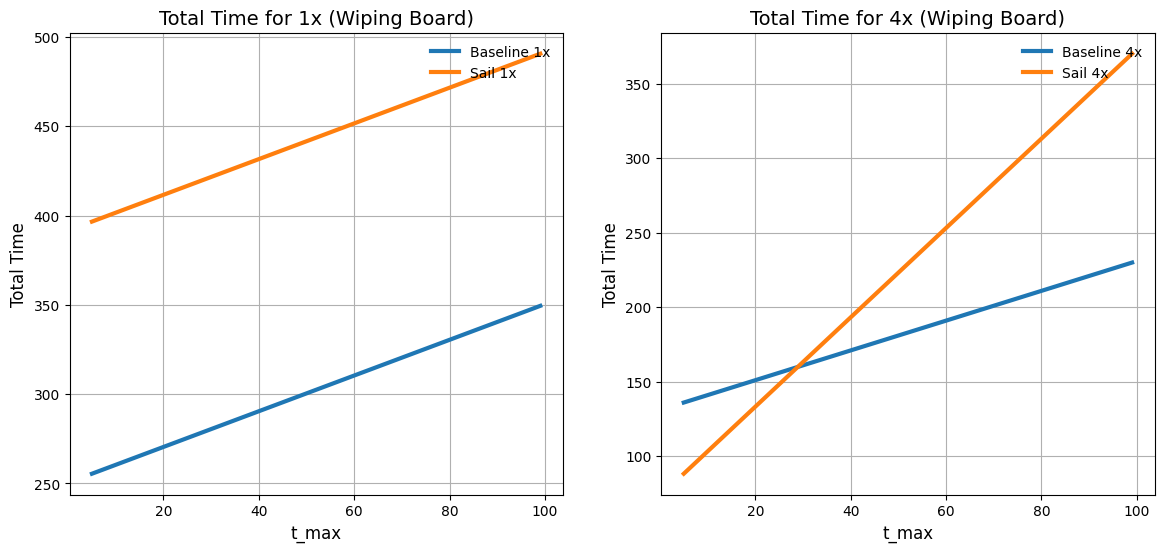

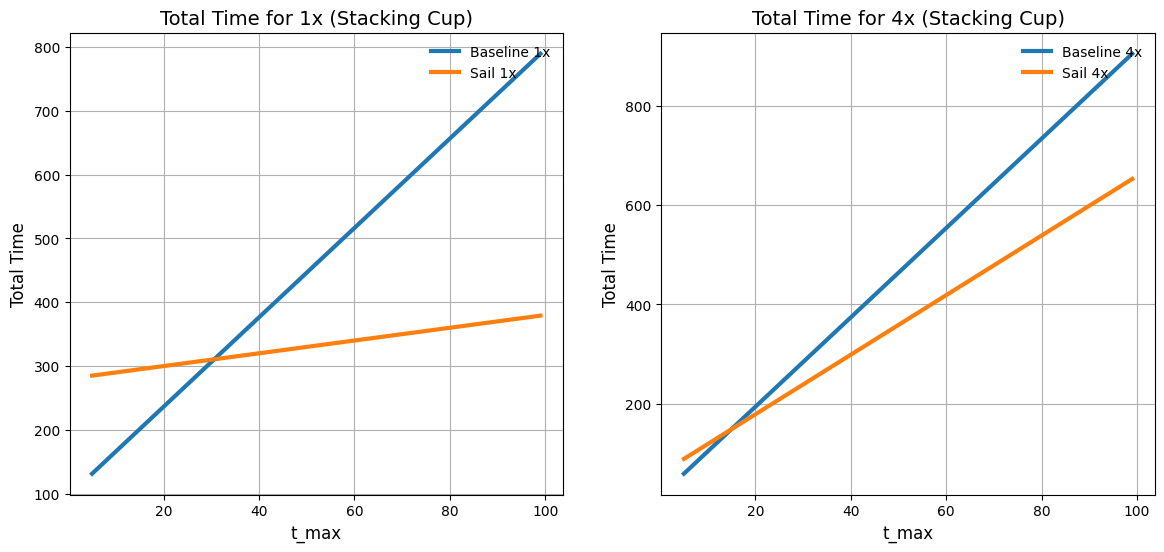

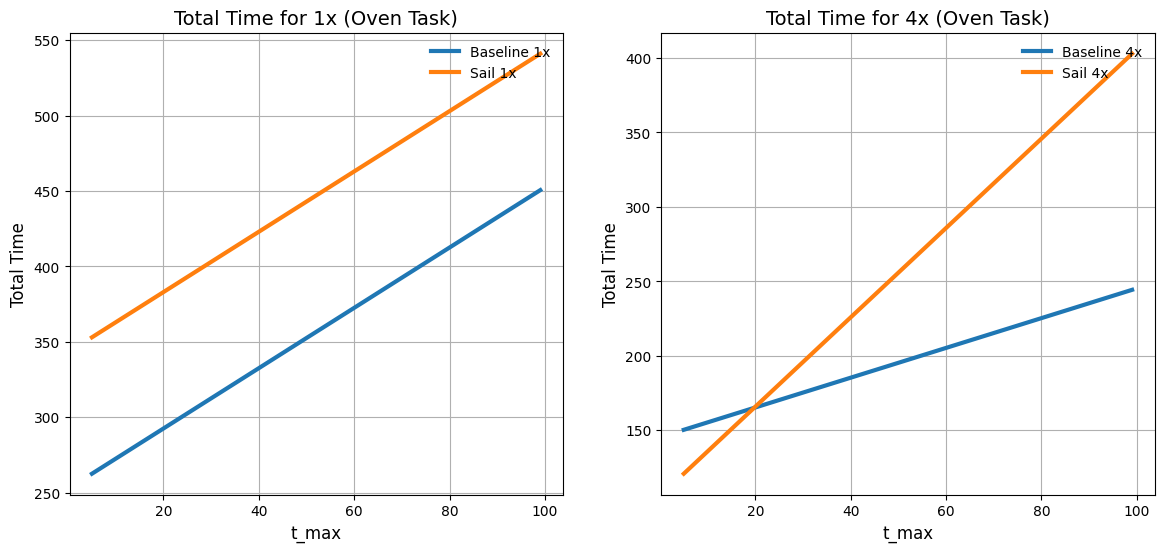

In [27]:

def total_time(data_dict, t_max):
    # NOTE: must match the key in total_time template
    total_time = {"sail": {'1x': 0.0, '4x': 0.0}, "baseline": {'1x': 0.0, '4x': 0.0}}
    for speed_exp in total_time.keys():
        for speed in total_time[speed_exp].keys():
            total_time[speed_exp][speed] = np.sum(np.where(data_dict[speed_exp][speed]['success'] == 1, data_dict[speed_exp][speed]['time'], t_max))
    return total_time

print(f"total time {total_time(wiping_board, 100)}")
print(f"total time {total_time(stacking_cup, 100)}")
print(f"total time {total_time(oven_task, 100)}")

tasks = [wiping_board, stacking_cup, oven_task]
task_names = ["Wiping Board", "Stacking Cup", "Oven Task"]

for task, task_name in zip(tasks, task_names):
    t_max_range = range(5, 100)
    total_time_results = {"sail": {'1x': [], '4x': []}, "baseline": {'1x': [], '4x': []}}

    for t_max in t_max_range:
        total_time_result = total_time(task, t_max)
        for speed_exp in total_time_result.keys():
            for speed in total_time_result[speed_exp].keys():
                total_time_results[speed_exp][speed].append(total_time_result[speed_exp][speed])

    fig, axs = plt.subplots(1, 2, figsize=(14, 6))

    # Plot for 1x
    axs[0].plot(t_max_range, total_time_results['baseline']['1x'], label='Baseline 1x', linewidth=3)
    axs[0].plot(t_max_range, total_time_results['sail']['1x'], label='Sail 1x', linewidth=3)
    axs[0].set_title(f'Total Time for 1x ({task_name})', fontsize=14)
    axs[0].set_xlabel('t_max', fontsize=12)
    axs[0].set_ylabel('Total Time', fontsize=12)
    axs[0].legend(loc='upper right', fontsize=10, frameon=False)
    axs[0].grid(True)

    # Plot for 4x
    axs[1].plot(t_max_range, total_time_results['baseline']['4x'], label='Baseline 4x', linewidth=3)
    axs[1].plot(t_max_range, total_time_results['sail']['4x'], label='Sail 4x', linewidth=3)
    axs[1].set_title(f'Total Time for 4x ({task_name})', fontsize=14)
    axs[1].set_xlabel('t_max', fontsize=12)
    axs[1].set_ylabel('Total Time', fontsize=12)
    axs[1].legend(loc='upper right', fontsize=10, frameon=False)
    axs[1].grid(True)

    plt.show()


## TEST axis angle conversion:

In [80]:
import numpy as np
import robomimic.utils.transform_utils as TransUtils

norm_1 = np.array([-0.4139, -0.1445,  0.3068])
offest = np.array([-3.05779266,  0.18944931, -0.22256583])
scale = np.array([0.25356188, 0.72975111, 0.47144425])

# denorm
aa_1 = norm_1*scale + offest
print(aa_1)

aa_interp = np.array([3.11621613, -0.03631065, 0.05469748])

axis, angle = TransUtils.vec2axisangle(aa_interp) # interp one
axis1, angle1 = TransUtils.vec2axisangle(aa_1) # original

print(f"interp axis {axis} interp angle {angle} \n axis1 {axis1}, angle1 {angle1}")

test2 = np.array([ 3.11590365, -0.14297756, 0.05090214])
print(TransUtils.vec2axisangle(test2))

test1 = np.zeros((3,4,5))
test2 = np.arange(5)
print(np.reshape(test1, (-1)).shape)
print(test2, np.argmax(test2))

[-3.16274192  0.08400027 -0.07792673]
interp axis [ 0.99977814 -0.01164958  0.01754864] interp angle 3.1169076416368116 
 axis1 [-0.99934441  0.02654191 -0.02462283], angle1 3.164816754258045
(array([ 0.99881589, -0.04583205,  0.01631689]), 3.1195975969030774)
(60,)
[0 1 2 3 4] 4


In [1]:
import numpy as np

def axis_angle_to_rotation_matrix(axis_angle):
    """
    Convert an axis-angle representation (3D vector) to a rotation matrix.
    """
    angle = np.linalg.norm(axis_angle)
    if angle < 1e-8:  # Avoid division by zero
        return np.eye(3)
    axis = axis_angle / angle
    K = np.array([
        [0, -axis[2], axis[1]],
        [axis[2], 0, -axis[0]],
        [-axis[1], axis[0], 0]
    ])
    R = np.eye(3) + np.sin(angle) * K + (1 - np.cos(angle)) * np.dot(K, K)
    return R

def geodesic_distance(axis_angle1, axis_angle2):
    """
    Calculate the geodesic distance between two axis-angle representations.
    """
    R1 = axis_angle_to_rotation_matrix(axis_angle1)
    R2 = axis_angle_to_rotation_matrix(axis_angle2)
    R_relative = np.dot(R1.T, R2)  # Relative rotation matrix
    trace = np.trace(R_relative)
    trace = np.clip(trace, -1.0, 3.0)  # Ensure numerical stability
    angle = np.arccos((trace - 1) / 2)
    return angle

# Example usage
axis_angle1 = np.array([0.5, 0.3, 0.1])  # Example axis-angle vector
axis_angle2 = np.array([0.1, 0.5, 0.3])  # Another example axis-angle vector

distance = geodesic_distance(axis_angle1, axis_angle2)
print(f"Geodesic distance: {distance:.6f} radians")

Geodesic distance: 0.483965 radians


## TEST B-spline + angular velocity approximation

In [ ]:
import numpy as np
from scipy.spatial.transform import Rotation as R  # For axis-angle to rotation matrix conversion

def B_spline_basis(t, knots, degree):
    """
    Calculates the B-spline basis functions at time 't' given a knot vector and degree.
    """
    n = len(knots) - degree - 1
    N = np.zeros((n, 1))
    for i in range(n):
        if t >= knots[i] and t <= knots[i + degree + 1]:
            N[i] = basis_recursive(i, t, knots, degree)
    return N

def basis_recursive(i, t, knots, degree):
    """
    Recursive calculation of a single B-spline basis function.
    """
    if degree == 0:
        if knots[i] <= t <= knots[i + 1]:
            return 1
        else:
            return 0
    else:
        denominator = knots[i + degree + 1] - knots[i]
        if denominator == 0:
            return 0
        N_i = (t - knots[i]) / denominator * basis_recursive(i, t, knots, degree - 1)
        N_ip1 = (knots[i + degree + 1] - t) / denominator * basis_recursive(i + 1, t, knots, degree - 1)
        return N_i + N_ip1

def axis_angle_to_rotation_matrix(axis, angle):
    """
    Converts an axis-angle representation to a rotation matrix using Rodrigues' formula.
    """
    axis = axis / np.linalg.norm(axis)
    cos_theta = np.cos(angle)
    sin_theta = np.sin(angle)
    cross_prod_mat = np.array([
        [0, -axis[2], axis[1]],
        [axis[2], 0, -axis[0]],
        [-axis[1], axis[0], 0]
    ])
    return np.eye(3) + sin_theta * cross_prod_mat + (1 - cos_theta) * np.dot(cross_prod_mat, cross_prod_mat)

def continuous_fusion(translation_data, rotation_data, timestamps):
    """
    Performs continuous fusion of translation and rotation data using B-splines with axis-angle representation.
    """
    # Define B-spline parameters
    degree = 3  # Cubic B-spline
    knots = np.linspace(0, 1, degree + len(translation_data) + 1)  
    
    # Fit translation B-spline
    translation_b_spline = []
    for i in range(3):  # Loop through x, y, z components
        translation_b_spline.append(B_spline_basis(timestamps, knots, degree) @ translation_data[:, i])
    
    # Fit rotation B-spline (using axis-angle representation)
    rotation_b_spline = []
    for i in range(3):  # Loop through axis components
        axis_b_spline = B_spline_basis(timestamps, knots, degree) @ rotation_data[:, i]
        angle_b_spline = B_spline_basis(timestamps, knots, degree) @ rotation_data[:, 3]  # Angle component
        rotation_b_spline.append([axis_b_spline, angle_b_spline])
    
    # Generate fused motion data
    fused_data = []
    for t in timestamps:
        translation = np.array([b_spline[0][0] for b_spline in translation_b_spline])
        rotation_axis = np.array([b_spline[0][0] for b_spline in rotation_b_spline])
        rotation_angle = np.array([b_spline[1][0] for b_spline in rotation_b_spline])
        rotation_matrix = axis_angle_to_rotation_matrix(rotation_axis, rotation_angle)
        fused_data.append([translation, rotation_matrix])
    
    return fused_data